# Урок 1. Основные показатели розничной торговли и описательная статистика

## Курс
**«Анализ данных и статистика в розничной торговле одеждой на Python: теория и практика»**

### Цель урока

Научиться правильно описывать показатели розничной сети **до применения статистических критериев**.

В этом уроке мы работаем только на уровне **всей сети** и рассматриваем 9 основных KPI:

1. Выручка
2. Посетители
3. Чеки
4. Покупки
5. Конверсия
6. Длина чека
7. Средняя цена
8. Средний чек
9. Выручка на посетителя

Мы разберём:

- абсолютные и расчётные показатели;
- арифметическое, взвешенное, гармоническое и геометрическое средние;
- F1-меру на примере задачи классификации;
- квартили, перцентили и ранги;
- учебную взвешенную оценку магазина;
- медиану;
- дисперсию;
- стандартное отклонение;
- коэффициент вариации;
- правильную агрегацию KPI;
- сезонность;
- месячные коэффициенты сезонности;
- fashion-сезоны **S** и **W**;
- динамику показателей по сезонам;
- долю S и W в выручке и посетителях.

> Важный принцип курса: сначала понять экономический смысл показателя и правила его расчёта, а уже потом применять статистические методы.

## 1. Исходная учебная база

Мы используем синтетическую сеть из 50 магазинов одежды.

Период наблюдений:

- январь 2022 — август 2026;
- 56 месяцев;
- 50 магазинов.

Исходный файл:

`Retail_50_Stores_Synthetic_v1.xlsx`

Для анализа используем лист:

`Данные_long`

На первом уроке **не сравниваем отдельные магазины**. Сначала агрегируем данные до уровня всей сети.

In [1]:
# --- Импорт библиотек ---
# pandas — таблицы и временные ряды;
# numpy — числовые операции (средние, произведения и т.п.);
# matplotlib.pyplot — графики;
# pathlib.Path — кроссплатформенная работа с путями к файлам.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Поиск файла с данными ---
# Возможные расположения:
#  1) рядом с notebook;
#  2) в подпапке ../../data/ (если notebook лежит глубоко в структуре репозитория);
#  3) в подпапке data/ рядом с notebook.
# Перебираем варианты по порядку и берём первый существующий.
filename = "Retail_50_Stores_Synthetic_v1.xlsx"
where = [Path(filename), Path("../../data") / filename, Path("data") / filename]
FILE = next((p for p in where if p.exists()), None)

# Если ни один путь не подошёл — даём понятную ошибку,
# а не падаем где-то ниже с непонятным traceback.
if FILE is None:
    raise FileNotFoundError(
        "Учебная книга не найдена. Скачайте её из папки data репозитория "
        "и сохраните рядом с notebook или сохраните структуру папок проекта."
    )

# --- Загрузка данных ---
# Читаем Excel-файл.
# sheet_name="Данные_long" — берём конкретный лист, название на русском.
# "long" в названии листа намекает на «длинный» формат данных (long format):
# каждая строка — это наблюдение (магазин × месяц × товар/метрика),
# в отличие от «широкого» формата, где метрики были бы разложены по столбцам.
df = pd.read_excel(FILE, sheet_name="Данные_long")

# Приводим столбец "Месяц" к типу datetime.
# Без этого не будут работать .dt.year, .dt.month, ресемплинг и т.д.
df["Месяц"] = pd.to_datetime(df["Месяц"])

# --- Базовая проверка содержимого ---
# Три метрики, чтобы убедиться, что данные ожидаемого объёма и периода.
print("Период:", df["Месяц"].min().date(), "—", df["Месяц"].max().date())

# Считаем число уникальных магазинов.
# nunique() возвращает количество уникальных значений в столбце "Магазин".
# По названию файла ожидается 50 магазинов — полезно сразу проверить.
print("Магазинов:", df["Магазин"].nunique())
print("Строк:", len(df))

# .head().T — транспонированный вывод первых 5 строк:
# в таком виде все столбцы видны вертикально, не надо прокручивать вправо.
display(df.head())

Период: 2022-01-01 — 2026-08-01
Магазинов: 50
Строк: 2800


,Месяц,Город,Магазин,План,Выручка,ВыручкаБезАкс,ВыручкаАкс,Посетители,Чеки,ПокупокБезАкс,...,Выполнение плана,Конверсия,Покупок на чек,Средняя цена,Средний чек,Доля аксессуаров,Валовая прибыль без ЗП,Маржинальность без ЗП,Валовая прибыль после ЗП,Маржинальность после ЗП
0,2022-01-01,Город1,Магазин1,3191594,3897749,3682172,215577,10694,638,1277,...,1.221255,0.059660,2.500000,2443.729781,6109.324451,0.055308,1302244,0.334102,852643.65,0.218753
1,2022-01-01,Город1,Магазин2,1659761,1385729,1295129,90600,6295,220,300,...,0.834897,0.034948,1.927273,3268.228774,6298.768182,0.065381,771610,0.556826,649312.24,0.468571
2,2022-01-01,Город1,Магазин3,2283147,2052870,1960650,92220,5785,238,457,...,0.899141,0.041141,2.428571,3551.678201,8625.504202,0.044922,1284949,0.625928,1080697.69,0.526433
3,2022-01-01,Город1,Магазин4,1865602,1956684,1765007,191677,4300,351,569,...,1.048822,0.081628,2.492877,2236.210286,5574.598291,0.097960,946869,0.483915,721871.23,0.368926
4,2022-01-01,Город1,Магазин5,2324944,2035011,1866329,168682,4478,243,512,...,0.875295,0.054265,3.152263,2656.672324,8374.530864,0.082890,1090226,0.535735,862528.57,0.423845


# 2. Девять основных показателей сети

Четыре показателя являются **абсолютными**:

$$
\text{Выручка}
$$

$$
\text{Посетители}
$$

$$
\text{Чеки}
$$

$$
\text{Покупки}
$$

Их можно суммировать по магазинам и периодам.

Например:

$$
\text{Выручка}_{янв-фев}
=
\text{Выручка}_{янв}
+
\text{Выручка}_{фев}
$$

Пять других KPI являются **расчётными**:

$$
\text{Конверсия} = \frac{\text{Чеки}}{\text{Посетители}}
$$

$$
\text{Длина чека} = \frac{\text{Покупки}}{\text{Чеки}}
$$

$$
\text{Средняя цена} = \frac{\text{Выручка}}{\text{Покупки}}
$$

$$
\text{Средний чек} = \frac{\text{Выручка}}{\text{Чеки}}
$$

$$
\text{Выручка\ на\ посетителя} = \text{Конверсия}*\text{Длина\ чека}*\text{Средняя\ цена}
$$

Их нельзя просто складывать и, как правило, нельзя агрегировать простым средним.

## 3. Формируем месячные показатели всей сети

Сначала суммируем абсолютные показатели по всем 50 магазинам.

После этого рассчитываем относительные KPI **заново из агрегированных числителей и знаменателей**.

**Примечание.** Если знаменатель равен нулю, расчётный KPI не определён: такие месяцы помечают `NaN`, а не заменяют нулём. В этом уроке сетевые знаменатели положительны.


In [3]:
# --- Сетевая витрина метрик по месяцам ---
# Цель блока — собрать агрегированные по всей сети магазинов показатели
# в разрезе месяцев: суммируем абсолютные метрики и вычисляем производные.

# Группируем исходный длинный DataFrame по столбцу "Месяц".
# as_index=False — ключевой параметр: без него "Месяц" стал бы индексом
# результата, а с ним остаётся обычным столбцом (удобнее для дальнейших
# операций, вывода и объединений).
network = (
    df.groupby("Месяц", as_index=False)
      # Named aggregation: для каждого агрегата явно указываем
      # (исходный столбец, функция) и имя результирующего столбца.
      .agg(
          Выручка=("Выручка", "sum"),        # суммарная выручка сети за месяц
          Посетители=("Посетители", "sum"),  # суммарный трафик за месяц
          Чеки=("Чеки", "sum"),              # суммарное число чеков
          Покупки=("Покупок", "sum")         # суммарное число купленных единиц
      )
)

# --- Производные (относительные) метрики ---
# Все считаются построчно (по каждому месяцу) как отношения уже
# просуммированных абсолютных показателей.
# Это даёт корректные сетевые метрики: отношение сумм, а не среднее отношений.

# Конверсия: доля посетителей, оформивших чек. Обычно 0..1.
network["Конверсия"] = network["Чеки"] / network["Посетители"]

# Длина чека: сколько единиц товара в среднем в одном чеке.
network["Длина чека"] = network["Покупки"] / network["Чеки"]

# Средняя цена: средняя цена одной единицы товара.
network["Средняя цена"] = network["Выручка"] / network["Покупки"]

# Средний чек: средняя сумма одного чека.
network["Средний чек"] = network["Выручка"] / network["Чеки"]

# Выручка на посетителя (revenue per visitor, ARPU-подобная метрика):
# сколько денег приносит один посетитель в среднем.
network["Выручка на посетителя"] = network["Выручка"] / network["Посетители"]

# Список метрик для дальнейшего анализа (графики, корреляции, модели).
# Порядок: сначала абсолютные, затем относительные — так удобнее читать.
METRICS = [
    "Выручка",
    "Посетители",
    "Чеки",
    "Покупки",
    "Конверсия",
    "Длина чека",
    "Средняя цена",
    "Средний чек",
    "Выручка на посетителя",
]


# --- Форматирование вывода через Styler ---
# Функции ниже форматируют ТОЛЬКО отображение таблицы.
# Сами значения в network остаются числами — это важно для расчётов и графиков.

def fmt_month(x):
    """Timestamp -> '2022-01'."""
    # Если значение пропущено — вернуть пустую строку,
    # чтобы Styler не падал на NaT.
    if pd.isna(x):
        return ""
    # strftime с шаблоном %Y-%m даёт строку вида "2022-01".
    return x.strftime("%Y-%m")

def fmt_int(x):
    """Целое с пробелом как разделителем разрядов: 1234567 -> '1 234 567'."""
    if pd.isna(x):
        return ""
    # round + int: аккуратно избавляемся от дробной части.
    # f"{n:,}" вставляет запятые как разделитель (1,234,567),
    # затем заменяем их на пробел — получаем "1 234 567".
    return f"{int(round(x)):,}".replace(",", " ")

def fmt_pct(x):
    """Доля -> проценты с одним знаком: 0.1234 -> '12.3%'."""
    if pd.isna(x):
        return ""
    # Умножаем на 100, чтобы перевести долю в проценты,
    # .1f даёт один знак после запятой.
    return f"{x * 100:.1f}%"

def fmt_dec2(x):
    """Десятичное с двумя знаками: 3.4567 -> '3.46'."""
    if pd.isna(x):
        return ""
    # .2f — ровно два знака после запятой, округление стандартное (банковское на float).
    return f"{x:.2f}"

# Словарь соответствия "имя столбца -> функция форматирования".
# Логика разбиения:
#   - Месяц: как "YYYY-MM";
#   - абсолютные и денежные метрики — целые с разделителем разрядов;
#   - Конверсия — проценты с одним знаком;
#   - Длина чека — два знака после запятой (там важны доли).
format_map = {
    "Месяц": fmt_month,
    "Выручка": fmt_int,
    "Посетители": fmt_int,
    "Чеки": fmt_int,
    "Покупки": fmt_int,
    "Средняя цена": fmt_int,
    "Средний чек": fmt_int,
    "Выручка на посетителя": fmt_int,
    "Конверсия": fmt_pct,
    "Длина чека": fmt_dec2,
}

# --- Финальный рендер таблицы через Styler ---
(
    network
    .style                            # создаём Styler поверх DataFrame
    .format(format_map)               # применяем формат по столбцам из словаря
    .set_caption("Сетевые метрики по месяцам")  # заголовок таблицы
    .set_properties(**{"text-align": "right"})  # выравнивание значений вправо
    .set_table_styles([               # тонкая настройка заголовка таблицы
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),     # разместить заголовок над таблицей
                ("font-weight", "bold"),     # сделать его жирным
            ]
        }
    ])
)

,Месяц,Выручка,Посетители,Чеки,Покупки,Конверсия,Длина чека,Средняя цена,Средний чек,Выручка на посетителя
0,2022-01,159 041 802,328 891,22 415,58 788,6.8%,2.62,2 705,7 095,484
1,2022-02,139 369 828,272 619,21 243,59 249,7.8%,2.79,2 352,6 561,511
2,2022-03,174 155 312,356 055,23 442,60 252,6.6%,2.57,2 890,7 429,489
3,2022-04,187 135 342,333 476,24 973,67 470,7.5%,2.70,2 774,7 494,561
4,2022-05,202 800 090,356 601,27 317,82 529,7.7%,3.02,2 457,7 424,569
5,2022-06,169 952 680,344 119,26 449,80 860,7.7%,3.06,2 102,6 426,494
6,2022-07,143 800 906,309 406,26 360,78 338,8.5%,2.97,1 836,5 455,465
7,2022-08,164 891 053,378 894,28 884,83 872,7.6%,2.90,1 966,5 709,435
8,2022-09,194 656 834,372 959,26 110,69 613,7.0%,2.67,2 796,7 455,522
9,2022-10,253 855 687,394 636,29 704,72 734,7.5%,2.45,3 490,8 546,643


# 4. Почему нельзя просто усреднять конверсию?

Рассмотрим условный пример.

| Месяц | Посетители | Чеки | Конверсия |
|---|---:|---:|---:|
| Январь | 10 000 | 1 000 | 10% |
| Февраль | 20 000 | 1 600 | 8% |

Наивное среднее:

$$
\frac{10\% + 8\%}{2}=9\%
$$

Но правильная конверсия за два месяца:

$$
\frac{1000+1600}{10000+20000}
=
8.67\%
$$

Почему возникла разница?

Потому что месяцы имеют разный объём посетителей.

Фактически итоговая конверсия является **взвешенным средним месячных конверсий**, где весом выступает количество посетителей.

In [5]:
# Создаём маленький синтетический DataFrame для иллюстрации.
# Два месяца с разным трафиком и числом чеков.
# Подчёркивания в числах (10_000) — синтаксический сахар Python 3.6+,
# визуально отделяют разряды, значение то же, что 10000.
example = pd.DataFrame({
    "Месяц": ["Январь", "Февраль"],
    "Посетители": [10_000, 20_000],
    "Чеки": [1_000, 1_600]
})

# Считаем конверсию для каждого месяца отдельно:
#   Январь:  1000 / 10000 = 0.10 = 10%
#   Февраль: 1600 / 20000 = 0.08 = 8%
# Это построчная (per-row) метрика — доля чеков от посетителей в конкретном месяце.
example["Конверсия"] = example["Чеки"] / example["Посетители"]

# --- Три разных способа "усреднить" конверсию ---

# 1) ПРОСТОЕ СРЕДНЕЕ: (10% + 8%) / 2 = 9%.
# Складываем конверсии двух месяцев и делим на 2.
# Ошибка: месяцы считаются равнозначными, хотя во втором трафик в 2 раза больше.
# Именно это обычно называют "наивным средним".
simple_mean = example["Конверсия"].mean()

# 2) ПРАВИЛЬНАЯ КОНВЕРСИЯ ЗА ДВА МЕСЯЦА:
#   (1000 + 1600) / (10000 + 20000) = 2600 / 30000 ≈ 0.0867 = 8.67%.
# Сначала суммируем числители и знаменатели, потом делим.
# Это "отношение сумм" — корректная агрегированная метрика за период.
correct_conversion = example["Чеки"].sum() / example["Посетители"].sum()

# 3) ВЗВЕШЕННОЕ СРЕДНЕЕ:
#   Σ(конверсия_i × вес_i) / Σ(вес_i), где вес — Посетители.
# Численно совпадает с (2), потому что:
#   Σ(Чеки_i / Посетители_i × Посетители_i) / ΣПосетители_i
#     = ΣЧеки_i / ΣПосетители_i.
# То есть взвешивание конверсий по трафику даёт ту же цифру, что и отношение сумм.
# np.average — функция NumPy: принимает массив значений и массив весов.
weighted_mean = np.average(
    example["Конверсия"],
    weights=example["Посетители"]
)

# Показываем исходную таблицу (в Jupyter отрисуется красиво).
display(example)

# Печатаем три числа в процентах с двумя знаками после запятой.
# Формат .2% сам умножает на 100 и добавляет знак %.
print(f"Простое среднее: {simple_mean:.2%}")            # 9.00%
print(f"Правильная конверсия: {correct_conversion:.2%}")  # 8.67%
print(f"Взвешенное среднее: {weighted_mean:.2%}")       # 8.67%

,Месяц,Посетители,Чеки,Конверсия
0,Январь,10000,1000,0.10
1,Февраль,20000,1600,0.08


Простое среднее: 9.00%
Правильная конверсия: 8.67%
Взвешенное среднее: 8.67%


## 5. Универсальное правило агрегирования расчётных KPI

Если показатель является отношением:

$$
KPI=\frac{Числитель}{Знаменатель}
$$

то для объединённого периода правильнее считать:

$$
KPI_{итого}
=
\frac{\sum Числитель}{\sum Знаменатель}
$$

а не:

$$
\frac{KPI_1+KPI_2+\dots+KPI_n}{n}
$$

Для наших показателей:

| KPI | Правильный расчёт за период |
|---|---|
| Конверсия | Σ Чеки / Σ Посетители |
| Длина чека | Σ Покупки / Σ Чеки |
| Средняя цена | Σ Выручка / Σ Покупки |
| Средний чек | Σ Выручка / Σ Чеки |
| Выручка на посетителя | Σ Выручка / Σ Посетители |

Это одно из важнейших правил практической розничной аналитики.

# 6. Среднее и взвешенное среднее

## Арифметическое среднее

Для набора наблюдений:

$$
x_1,x_2,\dots,x_n
$$

арифметическое среднее:

$$
\bar{x}=
\frac{x_1+x_2+\dots+x_n}{n}
$$

Оно отвечает на вопрос:

> Каков средний уровень показателя на одно наблюдение?

Например, средняя месячная выручка сети.

## Взвешенное среднее

Если наблюдения имеют разный вес:

$$
\bar{x}_w=
\frac{\sum w_i x_i}{\sum w_i}
$$

В розничной торговле веса часто возникают естественно:

- для конверсии — посетители;
- для длины чека — чеки;
- для средней цены — покупки;
- для среднего чека — чеки;
- для выручки на посетителя — посетители.

## 7. «Средняя месячная конверсия» и «конверсия за весь период» — разные вопросы

Это принципиально важно.

### Средняя месячная конверсия

$$
\frac{Conversion_{Jan}+...+Conversion_{Dec}}{12}
$$

каждый месяц имеет одинаковый вес.

### Конверсия сети за весь период

$$
\frac{\sum \text{Чеки}}{\sum \text{Посетители}}
$$

месяцы с большим числом посетителей имеют больший вес.

Оба расчёта могут быть корректными, но они отвечают **на разные аналитические вопросы**.

In [7]:
# --- Простое среднее конверсии по месяцам ---
# network["Конверсия"] — это Series с конверсией за каждый месяц
# (уже посчитанной как Чеки / Посетители внутри месяца).
# .mean() складывает все месячные конверсии и делит на число месяцев.
# ВАЖНО: этот способ считает все месяцы равнозначными,
# независимо от того, сколько в них было трафика.
# Это "наивное среднее" — оно почти всегда отличается от реальной
# конверсии за период и часто даёт смещённую оценку.
mean_monthly_conversion = network["Конверсия"].mean()

# --- Правильная конверсия за весь период ---
# Сначала суммируем числители (все чеки за все месяцы),
# затем суммируем знаменатели (все посетители за все месяцы),
# и только потом делим одно на другое.
# Это "отношение сумм" — корректная агрегированная метрика
# для метрик-отношений (конверсия, средний чек, средняя цена и т.п.).
# Эквивалентно взвешенному среднему месячных конверсий по числу посетителей.
period_conversion = (
    network["Чеки"].sum()
    / network["Посетители"].sum()
)

# --- Вывод результатов в процентах с двумя знаками после запятой ---
# Формат .2% автоматически умножает на 100 и добавляет знак "%".
print(f"Средняя месячная конверсия: {mean_monthly_conversion:.2%}")
print(f"Конверсия за весь период:   {period_conversion:.2%}")

Средняя месячная конверсия: 8.05%
Конверсия за весь период:   7.97%


# 8. Гармоническое среднее: когда усредняем ставки и отношения

Для положительных величин $x_1,\ldots,x_n$ гармоническое среднее:

$$
H=\frac{n}{\sum_{i=1}^{n}\frac{1}{x_i}}
$$

**Розничный пример.** Два вида товара имеют цены 2 000 и 4 000 руб. Покупатели потратили на каждый вид **одинаковую сумму** — по 12 000 руб. Куплено соответственно 6 и 3 штуки. Общая средняя цена: $24\,000 / 9 = 2\,666{,}67$ руб. Это гармоническое среднее двух цен, поскольку вес каждой цены по выручке одинаков. Арифметическое $3\,000$ руб. здесь неверно для общей цены единицы.

**Ограничение:** если одинаково количество **штук**, средняя цена будет арифметическим средним. В нашей базе общую среднюю цену по-прежнему рассчитываем как $\sum \text{Выручка}/\sum \text{Покупки}$; гармоническое среднее не заменяет универсальную формулу агрегации.

In [8]:
# --- Учебный пример: одинаковая выручка по двум товарным группам ---
# Идея: если на обе группы потратили одинаково, то количество штук
# обратно пропорционально цене. Средняя цена за штуку — это гармоническое среднее.
from scipy.stats import hmean

# Цены товаров и выручка по каждой группе (одинаковая — 12000 руб.).
prices = np.array([2_000.0, 4_000.0])
revenue_by_group = np.array([12_000.0, 12_000.0])

# Количество купленных единиц в каждой группе: штук = выручка / цена.
units = revenue_by_group / prices

# Правильная средняя цена единицы = общая выручка / общее число штук.
actual_asp = revenue_by_group.sum() / units.sum()

# hmean считает гармоническое среднее — совпадает с правильным результатом при равной выручке групп.
harmonic_asp = hmean(prices)

print(f"Общая средняя цена: {actual_asp:,.2f} руб.")
print(f"Гармоническое среднее цен: {harmonic_asp:,.2f} руб.")
print(f"Неверное арифметическое среднее: {prices.mean():,.2f} руб.")

# Контрольная проверка: два подхода должны совпасть.
assert np.isclose(actual_asp, harmonic_asp)

Общая средняя цена: 2,666.67 руб.
Гармоническое среднее цен: 2,666.67 руб.
Неверное арифметическое среднее: 3,000.00 руб.


**Интерпретация:** при одинаковой сумме расходов на дешёвый товар приобретают больше штук; поэтому общая цена единицы смещается к более дешёвому товару. В реальных данных веса групп обычно неодинаковы: используйте отношение общих сумм или соответствующее взвешенное гармоническое среднее.

## F-мера: гармоническое среднее двух характеристик классификации

F1-мера применяется, когда модель классифицирует объекты, например **предсказывает, какие магазины не выполнят план**. В этом примере «положительный класс» — невыполнение плана.

- **Precision (точность положительных предсказаний):** какая доля магазинов, отмеченных моделью как проблемные, действительно не выполнила план.
- **Recall (полнота):** какую долю всех действительно проблемных магазинов модель обнаружила.

$$
F_1=\frac{2\,Precision\,Recall}{Precision+Recall}
$$

F1 высока, когда обе характеристики достаточно высоки; если одна близка к нулю, гармоническое среднее резко падает. **F1 не является универсальной мерой успешности магазина** и не объединяет произвольно выручку, конверсию и средний чек.

In [9]:
# --- Учебный классификатор риска невыполнения плана ---
# TP (true positive)  — верно обнаружили риск;
# FP (false positive) — ложная тревога (сказали "риск", а план выполнен);
# FN (false negative) — пропущенный риск (сказали "ок", а план провален).
TP, FP, FN = 12, 3, 8

# Precision = TP / (TP + FP): доля верных среди всех предсказанных рисков.
precision = TP / (TP + FP)

# Recall = TP / (TP + FN): какую долю реальных рисков мы поймали.
recall = TP / (TP + FN)

# F1 — гармоническое среднее precision и recall (классическая формула).
f1_manual = 2 * precision * recall / (precision + recall)

# Проверка: hmean даёт то же значение, что и формула выше.
from scipy.stats import hmean
f1_harmonic = hmean([precision, recall])

print(f"Precision: {precision:.1%}; Recall: {recall:.1%}")
print(f"F1: {f1_manual:.3f}; гармоническое среднее: {f1_harmonic:.3f}")
assert np.isclose(f1_manual, f1_harmonic)

Precision: 80.0%; Recall: 60.0%
F1: 0.686; гармоническое среднее: 0.686


**Интерпретация:** модель нашла 12 из 20 фактически не выполнивших план магазинов, но выдала 3 ложные тревоги. F1 суммирует компромисс между точностью и полнотой; оценка денежных последствий пропуска риска требует дополнительного анализа.

# 8А. Геометрическое среднее: средний темп роста

Для **положительных** величин $x_i$:

$$
G=\left(\prod_{i=1}^{n}x_i\right)^{1/n}
$$

Когда $x_i$ — коэффициенты роста (например, $1{,}10$, $0{,}90$, $1{,}15$), средний геометрический темп:

$$
\bar g=\left(\prod_{i=1}^{n}(1+g_i)\right)^{1/n}-1
$$

**Почему не арифметическое среднее?** Рост на 20% и последующее снижение на 20% дают итоговый коэффициент $1{,}2\times0{,}8=0{,}96$, то есть минус 4%, а не ноль. Геометрическое среднее сохраняет накопленный эффект. Нулевые и отрицательные множители роста требуют отдельной обработки; при выручке за период $\le 0$ этот подход для CAGR не применяем.

In [10]:
# --- Учебный пример: почему важно геометрическое среднее для темпов ---
# Рост на 20% и падение на 20% дают итог 0.96 (минус 4%), а не 0.
factors = np.array([1.20, 0.80])
print("Арифметический средний темп:", f"{(factors.mean()-1):.2%}")   # 0.00%
print("Геометрический средний темп:", f"{(np.prod(factors)**(1/len(factors))-1):.2%}")  # -2.02%

# --- Фактические годовые темпы выручки учебной сети (2022–2025) ---
# Убираем неполный 2026, группируем по годам и суммируем выручку.
annual_revenue = (network.loc[network["Месяц"].dt.year <= 2025]
                  .assign(Год=lambda d: d["Месяц"].dt.year)
                  .groupby("Год")["Выручка"].sum())

# Годовые коэффициенты роста: 1 + pct_change.
annual_factors = annual_revenue.pct_change().dropna().add(1)

# Средний геометрический темп как произведение факторов в степени 1/n минус 1.
geo_growth = np.prod(annual_factors.to_numpy()) ** (1 / len(annual_factors)) - 1

# То же самое через формулу CAGR: (конец / начало)^(1/(n-1)) - 1.
same_via_cagr = (annual_revenue.iloc[-1]/annual_revenue.iloc[0]) ** (1/(len(annual_revenue)-1)) - 1

print("Годовая выручка (руб.):")
print(annual_revenue.to_string())
print(f"Геометрический среднегодовой темп 2022–2025: {geo_growth:.2%}")

# Оба способа должны дать одинаковый результат.
assert np.isclose(geo_growth, same_via_cagr)

Арифметический средний темп: 0.00%
Геометрический средний темп: -2.02%
Годовая выручка (руб.):
Год
2022    2316204205
2023    2487080717
2024    2327484179
2025    2085108624
Геометрический среднегодовой темп 2022–2025: -3.44%


**Интерпретация:** полученный темп показывает, с какой постоянной годовой скоростью должна была бы изменяться выручка от уровня 2022 года до уровня 2025 года. Он не описывает колебания отдельных месяцев и не является прогнозом.

# 8. Медиана

Медиана — значение, которое делит упорядоченный ряд пополам:

- 50% наблюдений ниже медианы;
- 50% выше.

Если распределение симметрично и без сильных выбросов, среднее и медиана часто близки.

Если имеются сильные пики, выбросы или асимметрия, они могут заметно различаться.

В розничной торговле это особенно актуально из-за:

- декабрьских пиков;
- распродаж;
- временных закрытий;
- аномально сильных месяцев;
- структурных изменений.

In [12]:
# Строим сводную таблицу: для каждой метрики из списка METRICS
# считаем два показателя — среднее и медиану по месяцам.
# network[METRICS] — это подтаблица только с нужными столбцами,
# .mean() и .median() возвращают Series, индексированные именами метрик.
# pd.DataFrame({...}) собирает их в один DataFrame, где:
#   индекс строки — имя метрики,
#   столбцы — "Среднее" и "Медиана".
mean_median = pd.DataFrame({
    "Среднее": network[METRICS].mean(),
    "Медиана": network[METRICS].median()
})

# Считаем относительное отклонение среднего от медианы в процентах:
#   (Среднее / Медиана - 1) * 100
# Смысл метрики:
#   > 0  — среднее выше медианы (распределение скошено вправо, есть крупные "хвосты");
#   < 0  — среднее ниже медианы (скос влево, есть аномально низкие значения);
#   ≈ 0  — распределение примерно симметричное, среднее и медиана близки.
# Умножение на 100 переводит долю в проценты — удобнее читать.
mean_median["Разница_%_от_медианы"] = (
    mean_median["Среднее"] / mean_median["Медиана"] - 1
) * 100

# Показываем таблицу, округляя все числа до 3 знаков после запятой.
# Округление — только для отображения, сами значения в mean_median не меняются.
display(mean_median.round(3))

,Среднее,Медиана,Разница_%_от_медианы
Выручка,1.849288e+08,1.765649e+08,4.737
Посетители,2.807303e+05,2.777395e+05,1.077
Чеки,2.238784e+04,2.254000e+04,-0.675
Покупки,6.370945e+04,6.225300e+04,2.340
Конверсия,8.100000e-02,8.100000e-02,-0.186
Длина чека,2.856000e+00,2.851000e+00,0.195
Средняя цена,2.955257e+03,2.898076e+03,1.973
Средний чек,8.358878e+03,8.303317e+03,0.669
Выручка на посетителя,6.713390e+02,6.609180e+02,1.577


## Что делает код в целом
Собирает среднее и медиану по всем метрикам из METRICS в один DataFrame.

Вычисляет относительную разницу между средним и медианой в процентах. Это безразмерная метрика, позволяющая сравнивать признаки с разными масштабами (например, Выручка в миллионах и Конверсия в долях).

Выводит результат, округлённый до трёх знаков — для читаемости

## Как интерпретировать результат
Разница_%_от_медианы ≈ 0 — распределение симметричное, среднее и медиана почти совпадают.

Разница_%_от_медианы > 0 — правый скос (положительная асимметрия): есть месяцы с аномально высокими значениями, они «тянут» среднее вверх. Медиана устойчивее и лучше отражает типичное значение.

Разница_%_от_медианы < 0 — левый скос: есть аномально низкие значения (например, «провальные» месяцы), они «тянут» среднее вниз.

Большая разница (например, > 20–30%) — сигнал, что среднее как метрика «типичного» значения ненадёжно. В отчётах стоит показывать медиану или обе цифры.

Для метрик-отношений (Конверсия, Средний чек, Длина чека, Средняя цена) интерпретация сложнее: эти значения сами по себе — агрегаты, и их «среднее по месяцам» — это наивное среднее, а не реальная метрика за период. Разница тут показывает разброс между месяцами, но не «правильность» среднего.

# 8Б. Квартили, перцентили и интерквартильный размах

**Перцентиль $P_p$** — значение, ниже которого находится примерно $p$ процентов наблюдений, в зависимости от принятого правила интерполяции. Квартили — частный случай: $Q_1=P_{25}$, $Q_2=P_{50}$ (медиана), $Q_3=P_{75}$.

$$
IQR=Q_3-Q_1
$$

В Python `quantile(..., interpolation="linear")` использует линейную интерполяцию и соответствует принятому в Excel подходу `PERCENTILE.INC` / `ПЕРСЕНТИЛЬ.ВКЛ` при одном и том же наборе чисел. Не путайте **значение перцентиля** с **процентным рангом** (`PERCENTRANK.INC`, `ПРОЦЕНТРАНГ.ВКЛ`): первое ищет значение по проценту, второе — процентное положение заданного значения.

,"Выручка сети, руб."
P10,"137,209,750"
Q1 = P25,"156,506,262"
Медиана = P50,"176,564,870"
Q3 = P75,"201,137,960"
P90,"255,102,992"


Интерквартильный размах: 44,631,698 руб.


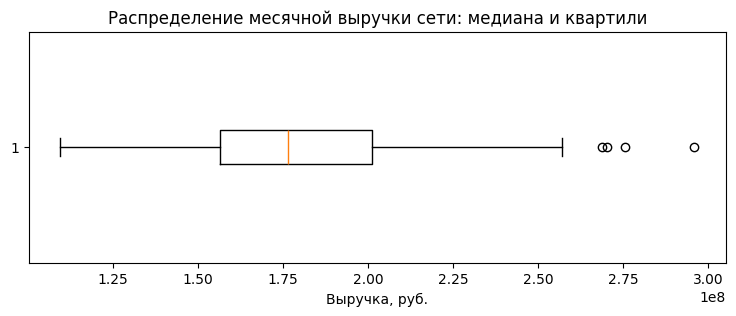

In [13]:
# --- Квантили месячной выручки сети ---
# Каждый месяц — одно наблюдение; dropna() убирает гипотетические пропуски.
monthly_revenue = network["Выручка"].dropna()

# Берём 5 квантилей: 10%, 25%, 50%, 75%, 90%.
# interpolation="linear" — как в Excel PERCENTILE.INC / ПЕРСЕНТИЛЬ.ВКЛ.
quantiles = monthly_revenue.quantile([0.10, 0.25, 0.50, 0.75, 0.90], interpolation="linear")
quantiles.index = ["P10", "Q1 = P25", "Медиана = P50", "Q3 = P75", "P90"]

# Styler.format("{:,.0f}") выводит значения с разделителем разрядов без знаков после запятой.
display(quantiles.to_frame("Выручка сети, руб.").style.format("{:,.0f}"))

# IQR — разница между третьим и первым квартилями, длина "центральной половины".
iqr = monthly_revenue.quantile(0.75) - monthly_revenue.quantile(0.25)
print(f"Интерквартильный размах: {iqr:,.0f} руб.")

# Boxplot: медиана + квартили + выбросы одной картинкой.
plt.figure(figsize=(9,3))
plt.boxplot(monthly_revenue, vert=False)
plt.title("Распределение месячной выручки сети: медиана и квартили")
plt.xlabel("Выручка, руб.")
plt.show()

**Интерпретация:** между Q1 и Q3 лежит центральная половина месячных значений. P90 описывает верхнюю часть распределения месяцев, но не гарантирует, что каждый десятый месяц будет именно таким. Месячная выручка зависит от сезона и тренда; перцентили здесь описательные, а не прогнозные границы.

# 9. Дисперсия, стандартное отклонение и коэффициент вариации

Среднее показывает **уровень** показателя.

Но два ряда с одинаковым средним могут иметь совершенно разную стабильность.

## Дисперсия

$$
s^2=
\frac{\sum(x_i-\bar{x})^2}{n-1}
$$

## Стандартное отклонение

$$
s=\sqrt{s^2}
$$

Оно показывает характерный масштаб отклонения наблюдений от среднего.

Но стандартные отклонения показателей с разными единицами измерения нельзя напрямую сравнивать.

Например:

- выручка измеряется в рублях;
- посетители — в людях;
- конверсия — в долях.

Поэтому для сравнения изменчивости разных KPI полезен **коэффициент вариации**.

## 10. Коэффициент вариации

$$
CV=
\frac{s}{\bar{x}}\times100\%
$$

Он показывает размер стандартного отклонения относительно среднего уровня показателя.

Чем выше CV, тем сильнее относительная изменчивость показателя.

> Важно: CV — описательная характеристика. Высокий CV сам по себе не говорит, хорошо это или плохо для бизнеса. Сначала нужно понять причины изменчивости.

Этот блок строит расширенную описательную статистику по всем сетевым метрикам и добавляет коэффициент вариации (CV) — безразмерную меру разброса, позволяющую сравнивать метрики с разными масштабами.

In [16]:
# Собираем описательные статистики по всем метрикам из METRICS
# в один DataFrame. Каждый вызов метода возвращает Series,
# индексированный именами метрик, — их объединяем в столбцы.
descriptive = pd.DataFrame({
    # Среднее арифметическое по месяцам: Σx / n.
    # Чувствительно к выбросам, хорошо работает для симметричных распределений.
    "Среднее": network[METRICS].mean(),

    # Медиана — 50-й процентиль: значение, которое делит выборку пополам.
    # Устойчива к выбросам и скошенности, отражает "типичное" значение.
    "Медиана": network[METRICS].median(),

    # Дисперсия — средний квадрат отклонения от среднего.
    # ddof=1 — "выборочная" дисперсия (делим на n-1, а не на n).
    # Это корректная оценка для выборки, а не для генеральной совокупности.
    # Важно: pandas по умолчанию использует ddof=1, но указание явно — хорошая практика.
    "Дисперсия": network[METRICS].var(ddof=1),

    # Стандартное отклонение — корень из дисперсии.
    # Возвращает разброс в тех же единицах, что и исходная метрика,
    # поэтому интерпретируется легче, чем дисперсия (которая в квадрате единиц).
    "Стандартное отклонение": network[METRICS].std(ddof=1),
})

# Добавляем Коэффициент вариации (CV, coefficient of variation):
#   CV = σ / μ
# Безразмерная мера относительного разброса. Позволяет сравнивать
# "шумность" метрик с разными масштабами (например, Выручку в рублях
# и Конверсию в долях). Чем больше CV, тем сильнее метрика "гуляет".

descriptive["CV_%"] = (
    descriptive["Стандартное отклонение"]
    / descriptive["Среднее"]*100
 )

#Форматирование. Для читаемого вывода применяем Styler
(
    descriptive
    .style
    .format({
        "Среднее": "{:,.3f}",
        "Медиана": "{:,.3f}",
        "Дисперсия": "{:,.0f}",
        "Стандартное отклонение": "{:,.3f}",
        "CV_%": "{:.1f}%",
    })
    .set_caption("Описательные статистики сетевых метрик")
)



,Среднее,Медиана,Дисперсия,Стандартное отклонение,CV_%
Выручка,"184,928,829.768","176,564,870.000","1,852,987,908,043,054","43,046,346.048",23.3%
Посетители,"280,730.268","277,739.500","4,505,375,505","67,122.094",23.9%
Чеки,"22,387.839","22,540.000","22,201,649","4,711.863",21.0%
Покупки,"63,709.446","62,253.000","175,031,807","13,229.959",20.8%
Конверсия,0.081,0.081,0,0.006,7.7%
Длина чека,2.856,2.851,0,0.200,7.0%
Средняя цена,"2,955.257","2,898.076","383,486",619.262,21.0%
Средний чек,"8,358.878","8,303.317","1,986,503","1,409.434",16.9%
Выручка на посетителя,671.339,660.918,"12,825",113.248,16.9%


## Что делает код в целом
Собирает четыре описательные статистики по каждой метрике:

среднее — центр распределения;

медиана — устойчивый центр;

дисперсия — квадратичный разброс;

стандартное отклонение — разброс в исходных единицах.

Вычисляет коэффициент вариации — относительный разброс в процентах, позволяющий сравнивать метрики с разными масштабами.

Выводит таблицу, округлённую до трёх знаков

## Как интерпретировать результат
Среднее vs Медиана — та же логика, что и в предыдущем блоке: расхождение говорит о скошенности.

Дисперсия — полезна для математических выкладок (например, при сложении независимых величин дисперсии складываются), но плохо читается «на глаз», потому что её размерность — квадрат исходной.

Стандартное отклонение — «типичное» отклонение от среднего в единицах метрики:

для Выручки — в рублях;

для Конверсии — в долях (например, σ = 0.02 означает ±2 п.п.);

для Среднего чека — в рублях.

CV_% — универсальная мера относительной изменчивости. Грубые ориентиры:

< 10% — низкая вариабельность, метрика стабильна;

10–25% — умеренная;

25–50% — высокая;

50% — очень высокая (часто признак сильной сезонности или нестабильности процесса).

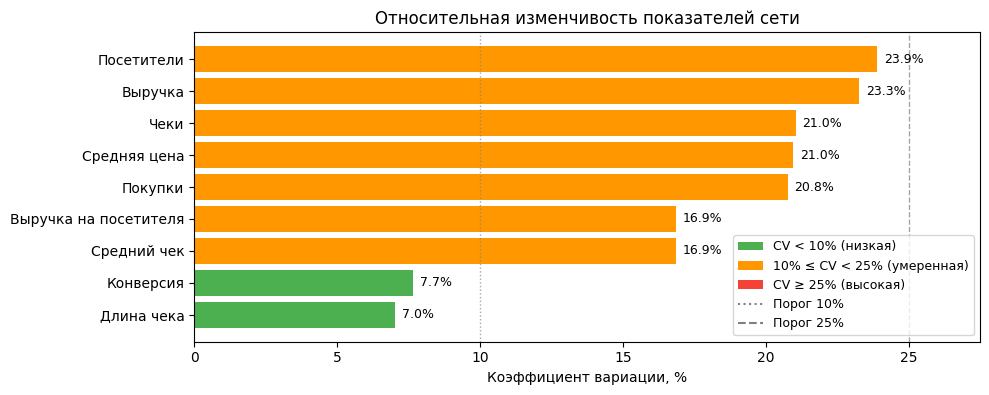

In [17]:
# Этот блок строит горизонтальную столбчатую диаграмму коэффициентов вариации (CV) по всем сетевым метрикам,
#отсортированных по возрастанию — наглядный способ сразу увидеть, какие показатели самые «шумные», а какие — стабильные.
# Берём столбец CV_% из таблицы descriptive и сортируем по возрастанию.
# sort_values() без аргументов сортирует по значениям (не по индексу).
# Получаем Series, где индекс — имена метрик, значения — CV в процентах,
# отсортированные от самых стабильных к самым изменчивым.
# --- Подготовка данных ---
# Берём CV_% из descriptive и сортируем по возрастанию:
# от самых стабильных метрик к самым изменчивым.
cv = descriptive["CV_%"].sort_values()

# --- Цветовая кодировка по уровню изменчивости ---
# Ориентиры (эвристика из практики):
#   CV < 10%   — низкая вариабельность  → зелёный
#   10–25%     — умеренная              → оранжевый
#   ≥ 25%      — высокая                → красный
def cv_color(value):
    if value < 10:
        return "#4caf50"   # зелёный
    elif value < 25:
        return "#ff9800"   # оранжевый
    return "#f44336"       # красный

colors = [cv_color(v) for v in cv.values]

# --- Построение графика ---
fig, ax = plt.subplots(figsize=(10, max(4, len(cv) * 0.45)))

# Горизонтальные столбцы с индивидуальным цветом.
# y = cv.index (названия метрик), width = cv.values (значения CV в %).
ax.barh(cv.index, cv.values, color=colors)

# Вертикальные линии пороговых значений CV.
# Пунктир / штрих-пунктир / сплошная — чтобы визуально различались.
for threshold, style, label in [
    (10, ":",  "10% — низкая / умеренная"),
    (25, "--", "25% — умеренная / высокая"),
]:
    ax.axvline(
        threshold,
        linestyle=style,
        color="gray",
        alpha=0.7,
        linewidth=1
    )

# Подписи значений прямо на столбцах:
# чуть правее конца столбца, по центру по вертикали.
# x_offset подобран так, чтобы текст не наезжал на столбец.
x_max = cv.values.max()
x_offset = x_max * 0.01
for i, (name, value) in enumerate(cv.items()):
    ax.text(
        value + x_offset,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=9,
        color="black"
    )

# --- Подписи осей и заголовок ---
ax.set_xlabel("Коэффициент вариации, %")
ax.set_title("Относительная изменчивость показателей сети")

# Небольшой запас справа, чтобы подписи значений не упирались в край.
ax.set_xlim(0, x_max * 1.15)

# --- Легенда ---
# Собираем кастомные «ручки» для легенды: цвета + линии порогов.
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor="#4caf50", label="CV < 10% (низкая)"),
    Patch(facecolor="#ff9800", label="10% ≤ CV < 25% (умеренная)"),
    Patch(facecolor="#f44336", label="CV ≥ 25% (высокая)"),
    Line2D([0], [0], color="gray", linestyle=":",  label="Порог 10%"),
    Line2D([0], [0], color="gray", linestyle="--", label="Порог 25%"),
]
ax.legend(
    handles=legend_elements,
    loc="lower right",
    fontsize=9,
    frameon=True
)

# Автоматическая подгонка отступов, чтобы подписи не обрезались.
plt.tight_layout()
plt.show()

## Что делает код в целом
Берёт столбец CV_% из таблицы descriptive (построенной в предыдущем блоке).

Сортирует метрики по возрастанию CV — от самых стабильных к самым изменчивым.

Строит горизонтальную столбчатую диаграмму, где:

по оси Y — названия метрик,

по оси X — значение CV в процентах,

длина столбца визуально кодирует изменчивость.

## Как читать график
Короткие столбцы внизу — метрики со стабильной динамикой. Например, Посетители или Чеки часто имеют низкий CV, если трафик по месяцам примерно ровный.

Длинные столбцы вверху — метрики с высокой изменчивостью. Часто это Конверсия или Средний чек — они сильнее реагируют на сезонность, акции, поведение покупателей.

Порядок сортировки помогает мгновенно выделить «проблемные» метрики — те, что скачут от месяца к месяцу.

Сравнение метрик между собой корректно именно потому, что CV безразмерен: Выручка в рублях и Конверсия в долях оказываются на одной шкале.

### Вопрос для анализа

Какие KPI наиболее стабильны?

Какие имеют высокую вариативность?

Не спешите трактовать высокий CV как проблему. В дальнейшем мы увидим, что значительная часть вариативности может иметь **систематическую сезонную природу**.

# 11. Экономическая архитектура показателей сети

Наши KPI связаны между собой.

$$
\text{Средний чек}
=
\text{Средняя цена}
\times
\text{Длина чека}
$$

Действительно:

$$
\frac{\text{Выручка}}{\text{Чеки}}
=
\frac{\text{Выручка}}{\text{Покупки}}
\times
\frac{\text{Покупки}}{\text{Чеки}}
$$

Ещё более важное равенство:

$$
\text{Выручка на посетителя}
=
\text{Конверсия}
\times
\text{Длина чека}
\times
\text{Средняя цена}
$$

И в итоге:

$$
\text{Выручка}
=
\text{Посетители}
\times
\text{Конверсия}
\times
\text{Длина чека}
\times
\text{Средняя цена}
$$

Это базовая факторная модель розничной сети.

In [19]:
#Этот блок — проверка корректности декомпозиции выручки: он пересчитывает ключевые метрики «с нуля» из множителей и
#сравнивает с исходными значениями в network.
# Делаем копию network, чтобы не портить исходный DataFrame.
# Все новые столбцы добавляем в копию — оригинал остаётся нетронутым.
check = network.copy()

# --- Проверка 1: средний чек ---
# По определению: Средний чек = Выручка / Чеки.
# Но также справедливо тождество:
#   Средний чек = (Выручка / Покупки) × (Покупки / Чеки)
#               = Средняя цена   × Длина чека.
# Пересчитываем средний чек через произведение двух факторов
# и сравниваем с исходным network["Средний чек"].
check["Средний чек из факторов"] = (
    check["Средняя цена"] * check["Длина чека"]
)

# --- Проверка 2: выручка на посетителя ---
# По определению: Выручка на посетителя = Выручка / Посетители.
# Разложим через цепочку отношений:
#   Выручка / Посетители
#     = (Чеки / Посетители) × (Покупки / Чеки) × (Выручка / Покупки)
#     = Конверсия × Длина чека × Средняя цена.
# Снова сравниваем с исходным значением.
check["Выручка на посетителя из факторов"] = (
    check["Конверсия"]
    * check["Длина чека"]
    * check["Средняя цена"]
)

# --- Проверка 3: выручка ---
# По определению: Выручка = Посетители × (Выручка / Посетители).
# Подставляя разложение выручки на посетителя:
#   Выручка = Посетители × Конверсия × Длина чека × Средняя цена.
# Это классическая мультипликативная декомпозиция:
#   Выручка = Трафик × Конверсия × Длина чека × Средняя цена.
check["Выручка из факторов"] = (
    check["Посетители"]
    * check["Конверсия"]
    * check["Длина чека"]
    * check["Средняя цена"]
)

# Показываем первые 5 строк с нужными столбцами в удобном порядке:
# для каждой исходной метрики рядом стоит её "факторная" версия,
# чтобы визуально убедиться, что значения совпадают.
display(
    check[
        [
            "Месяц",
            "Средний чек",
            "Средний чек из факторов",
            "Выручка на посетителя",
            "Выручка на посетителя из факторов",
            "Выручка",
            "Выручка из факторов",
        ]
    ].head()
)

,Месяц,Средний чек,Средний чек из факторов,Выручка на посетителя,Выручка на посетителя из факторов,Выручка,Выручка из факторов
0,2022-01-01,7095.329110,7095.329110,483.569943,483.569943,159041802,159041802.0
1,2022-02-01,6560.741327,6560.741327,511.225659,511.225659,139369828,139369828.0
2,2022-03-01,7429.200239,7429.200239,489.124748,489.124748,174155312,174155312.0
3,2022-04-01,7493.506667,7493.506667,561.165847,561.165847,187135342,187135342.0
4,2022-05-01,7423.951752,7423.951752,568.703088,568.703088,202800090,202800090.0


## Зачем вообще такая проверка
Убедиться в корректности ETL-пайплайна. Если все метрики посчитаны правильно, декомпозиция сойдётся. Любое расхождение — баг.

Подготовить факторный анализ. Когда разложение подтверждено, можно отвечать на вопросы вида «почему выручка упала в марте»:

упал ли трафик (Посетители);

упала ли конверсия;

уменьшилась ли длина чека;

снизилась ли средняя цена.
Каждое из этих изменений вносит вклад в итоговое изменение выручки.

# 12. Динамика KPI во времени

Теперь посмотрим на показатели сети с января 2022 по август 2026 года.

Временная динамика позволяет увидеть:

- рост или снижение;
- сезонные пики;
- повторяющийся рисунок;
- нестабильные периоды;
- возможные структурные изменения.

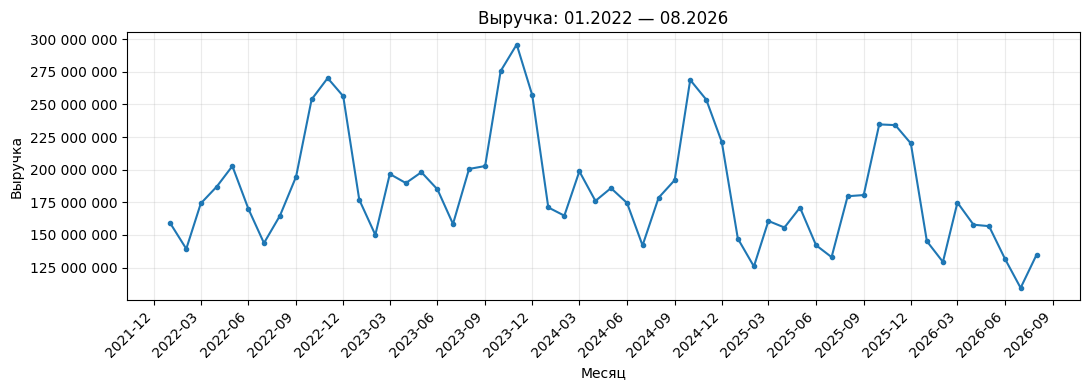

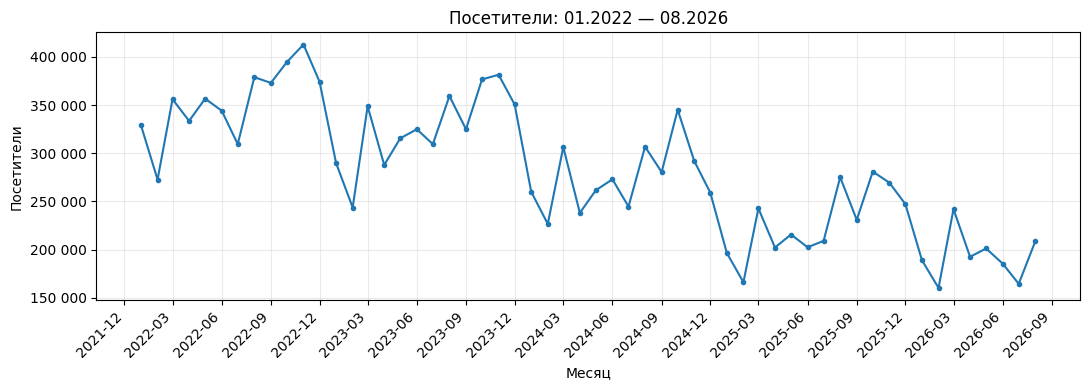

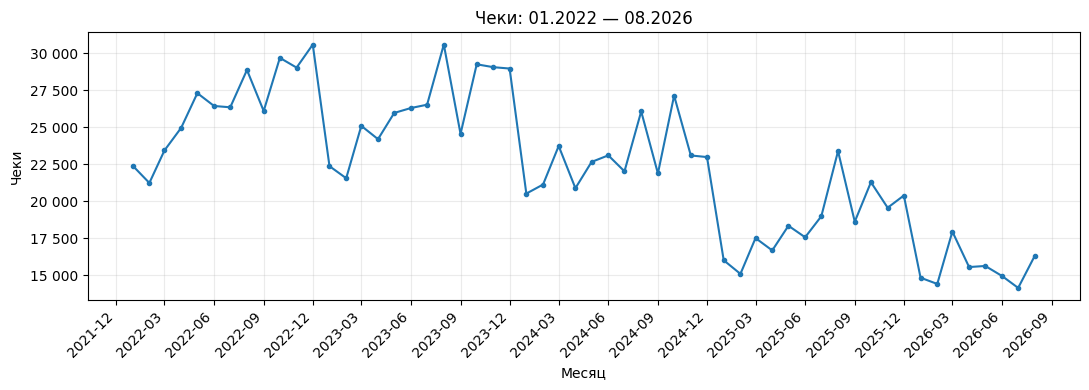

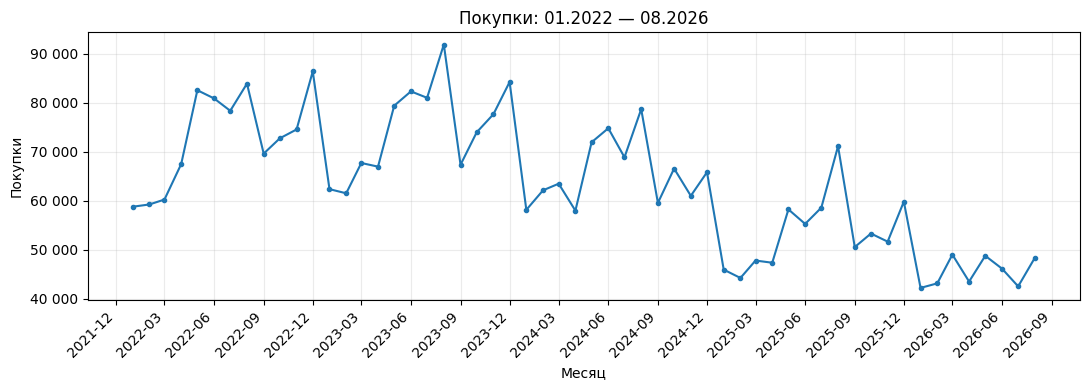

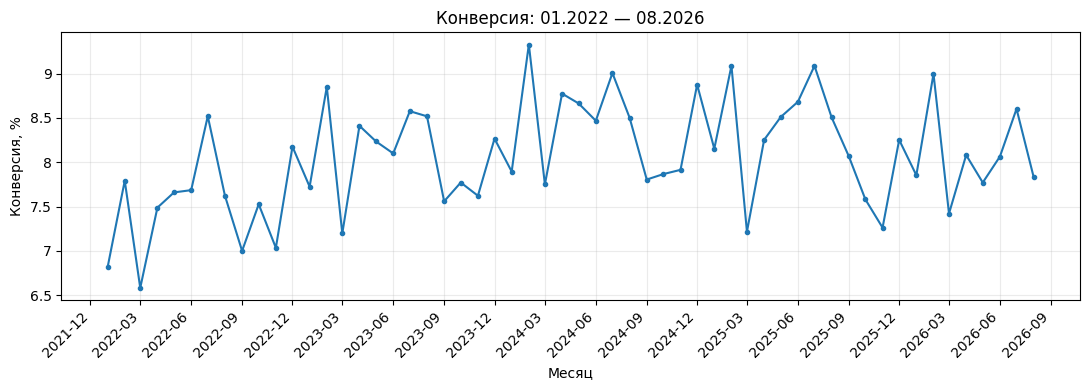

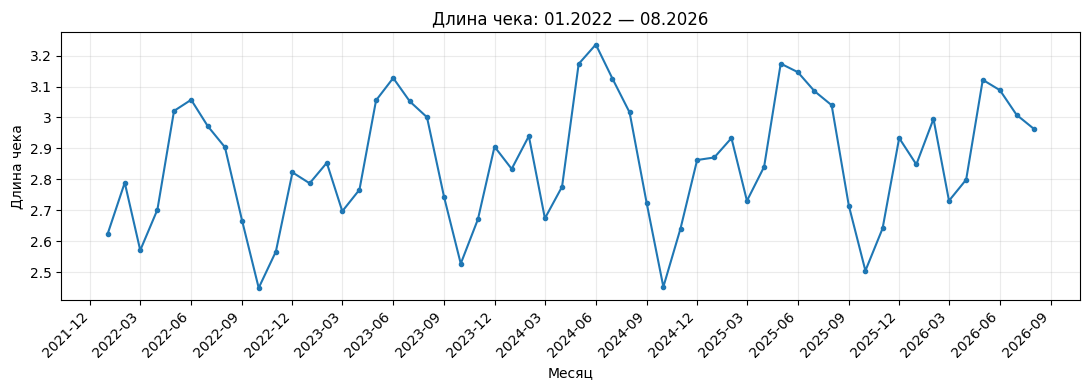

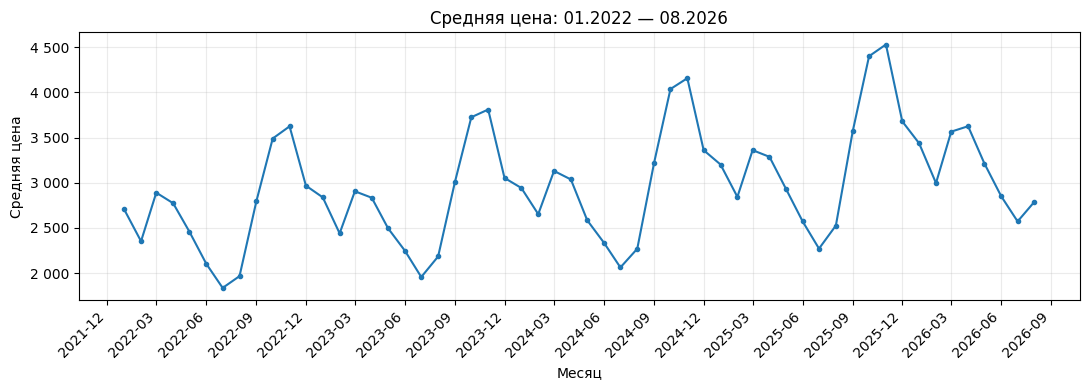

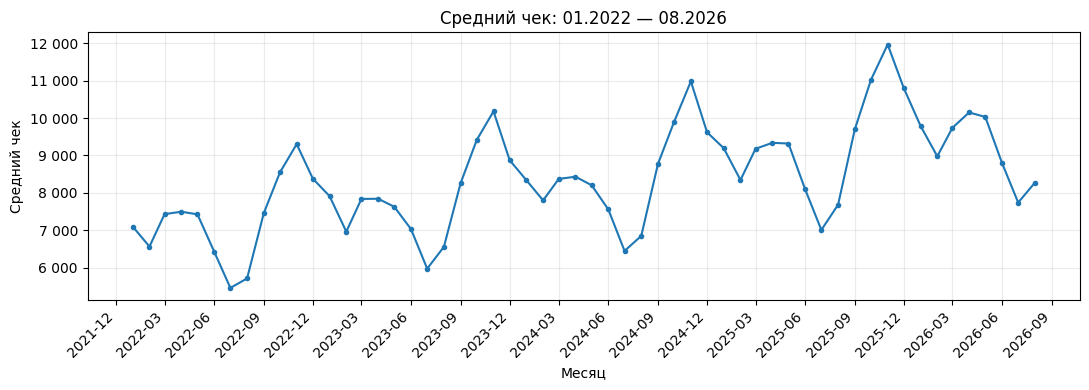

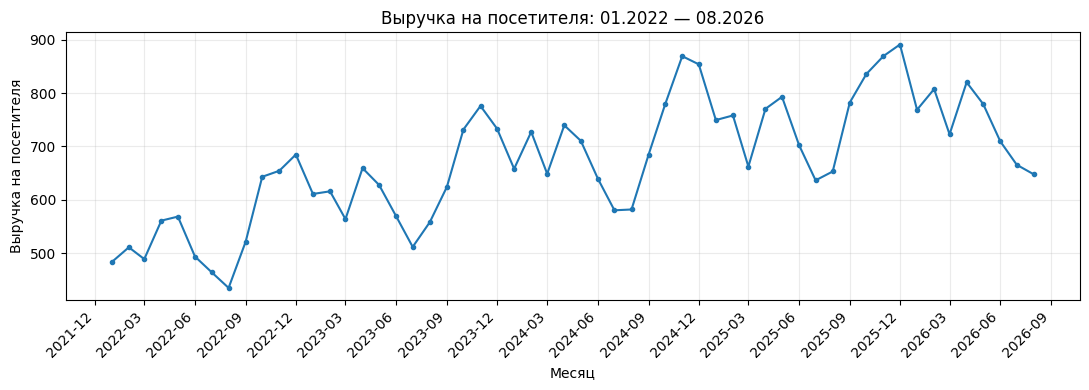

In [23]:
#Этот блок определяет универсальную функцию визуализации метрики по времени и применяет её ко всем девяти сетевым показателям.
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

def plot_metric(data, metric, percent=False, save_path=None):
    """
    Рисует линейный график метрики по месяцам.

    Параметры:
        data      — DataFrame с колонками "Месяц" и metric;
        metric    — название метрики (строкой), должно совпадать с именем столбца;
        percent   — если True, значения умножаются на 100 (для долей-метрик вроде конверсии);
        save_path — если задан, график сохраняется в файл (например, "plots/revenue.png").
    """
    # Создаём фигуру и ось. Работаем через fig, ax — так удобнее
    # настраивать отдельные элементы (даты, формат оси Y, сетку и т.д.).
    fig, ax = plt.subplots(figsize=(11, 4))

    # Если метрика — доля (например, конверсия 0.10 = 10%),
    # умножаем на 100, чтобы на оси Y были проценты, а не доли.
    y = data[metric] * 100 if percent else data[metric]

    # Линейный график по времени.
    # marker="o" с небольшим markersize — точки видны, но не «забивают» линию.
    ax.plot(data["Месяц"], y, marker="o", markersize=3, linewidth=1.5)

    # --- Автоматический период в заголовке ---
    # Берём минимальную и максимальную дату из данных.
    # strftime("%m.%Y") даёт компактный вид: "01.2022".
    first = data["Месяц"].min().strftime("%m.%Y")
    last = data["Месяц"].max().strftime("%m.%Y")
    ax.set_title(f"{metric}: {first} — {last}")

    # Подписи осей.
    ax.set_xlabel("Месяц")
    ax.set_ylabel(metric + (", %" if percent else ""))

    # --- Форматирование дат на оси X ---
    # Ставим метки раз в 3 месяца, чтобы подписи не слипались.
    # Формат "YYYY-MM" — привычный и однозначный.
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    # Наклоняем подписи на 45° для читаемости.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    # --- Форматирование значений на оси Y ---
    # Функция добавляет пробел как разделитель разрядов.
    # Для процентов и мелких значений (например, длины чека) суффикс " %" не нужен —
    # его добавляет подпись оси. Здесь только разделитель разрядов.
    def thousands_formatter(x, _):
        if abs(x) >= 1000:
            return f"{x:,.0f}".replace(",", " ")
        return f"{x:.2f}".rstrip("0").rstrip(".")

    ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

    # Сетка с прозрачностью 0.25 — не отвлекает, но помогает читать значения.
    ax.grid(alpha=0.25)

    # Автоматическая подгонка отступов, чтобы подписи дат не обрезались.
    plt.tight_layout()

    # --- Опциональное сохранение в файл ---
    # dpi=150 и bbox_inches="tight" дают аккуратную картинку для вставки в отчёт.
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()


# --- Строим графики для всех метрик ---
# Абсолютные метрики — без процентов.
plot_metric(network, "Выручка")
plot_metric(network, "Посетители")
plot_metric(network, "Чеки")
plot_metric(network, "Покупки")

# Конверсия — доля, поэтому percent=True: на оси Y будут проценты.
plot_metric(network, "Конверсия", percent=True)

# Относительные метрики — без процентов.
plot_metric(network, "Длина чека")
plot_metric(network, "Средняя цена")
plot_metric(network, "Средний чек")
plot_metric(network, "Выручка на посетителя")

## Что делает код в целом
Определяет функцию plot_metric, которая:

принимает DataFrame и имя метрики;

рисует линейный график метрики по времени;

умеет переводить доли в проценты (флаг percent=True);

подписывает оси и заголовок, добавляет сетку.

Вызывает её для каждой из девяти метрик, задавая percent=True только для конверсии.

Такой подход — «функция + вызовы» — предпочтительнее, чем копипаста одного и того же кода девять раз: если понадобится добавить подписи значений, изменить палитру или размер — правим одно место.

## Зачем это нужно
Единый шаблон визуализации даёт консистентную картину:

все графики одного размера;

одинаковый стиль сетки и подписей;

легко сравнивать метрики между собой;

можно быстро просмотреть всю динамику подряд.

## Как читать графики
Тренд. Растёт / падает / стабильна метрика на длинном горизонте.

Сезонность. Регулярные пики и спады с периодом 12 месяцев.
Аномалии. Разовые всплески или провалы — повод разобраться в причинах.

Связь между метриками. Если после просмотра всех графиков видно, что, например, Посетители и Выручка движутся синхронно, а Конверсия — в противофазе, это уже гипотеза для факторного анализа.

## 12А. Сопоставление годов на одной календарной оси

Для каждого KPI наложим линии 2022–2026 годов на одну ось **январь–декабрь**. Это помогает увидеть повторяемость календарного рисунка и отличить её от сдвига общего уровня. **2026 год неполный:** линия заканчивается в августе; сентябрь–декабрь не дорисовываем. Для сетевой выручки рублёвые значения, для конверсии — процентные пункты.

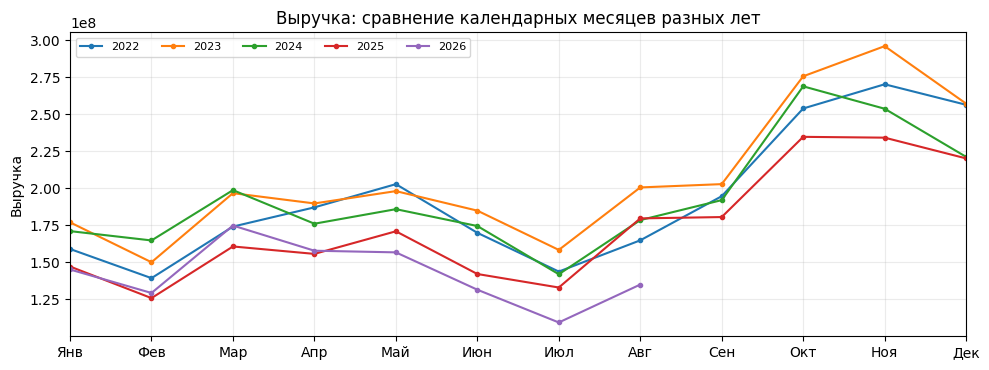

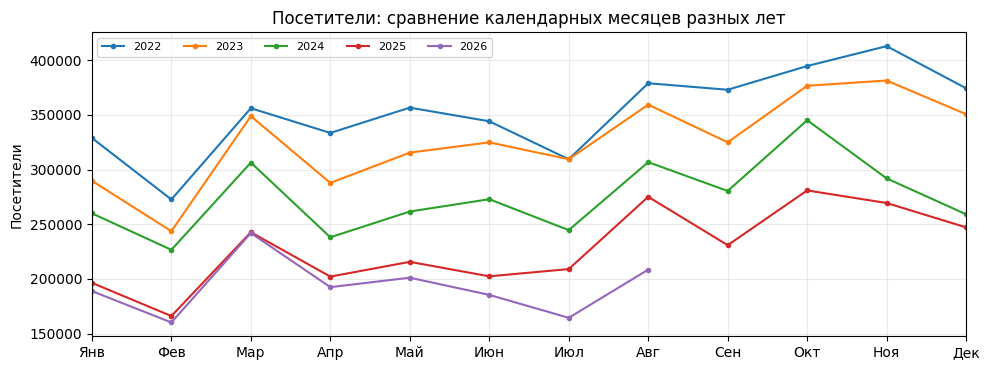

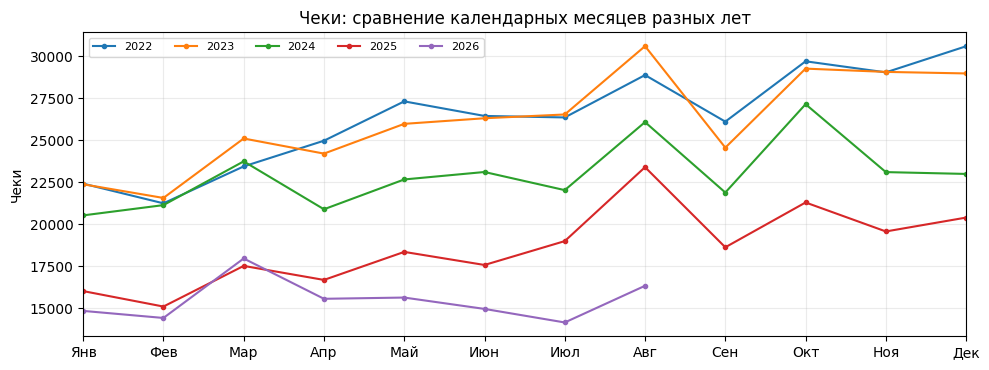

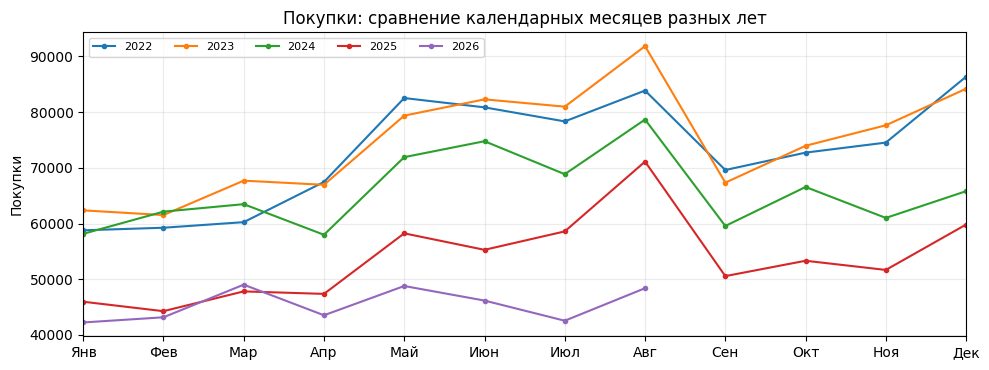

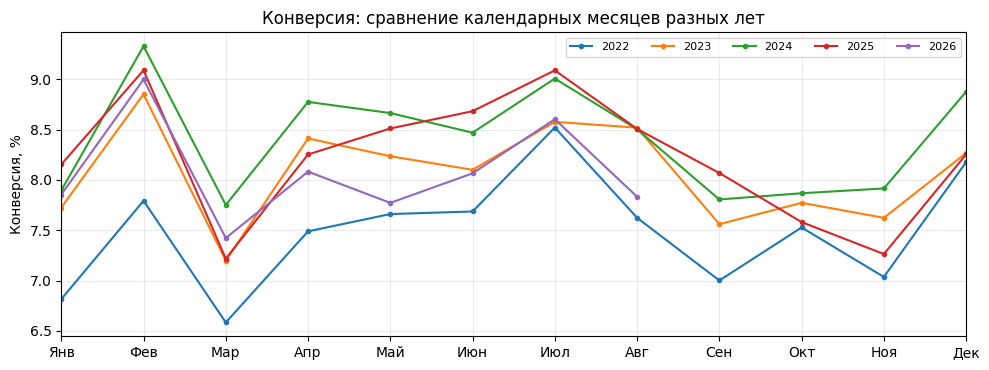

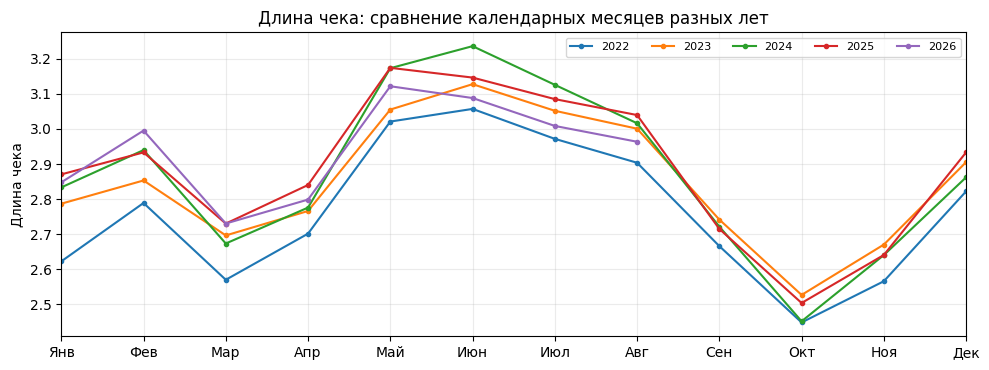

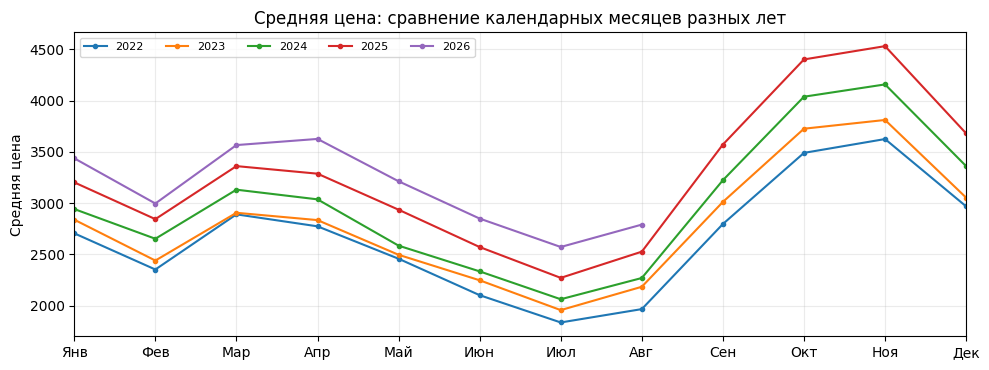

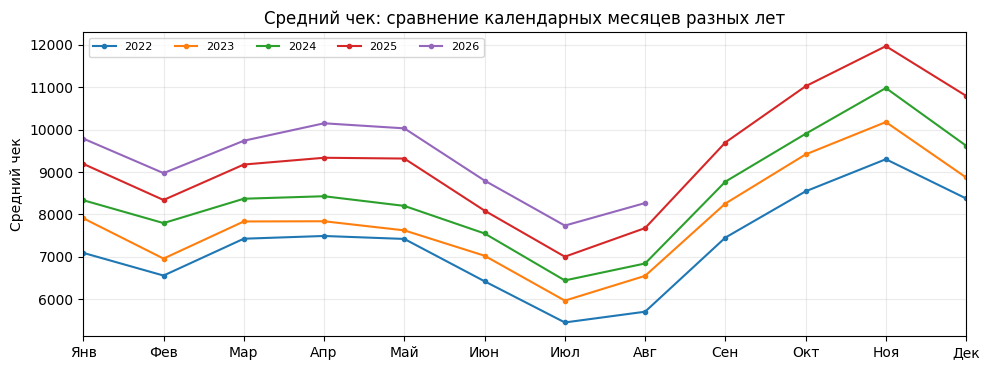

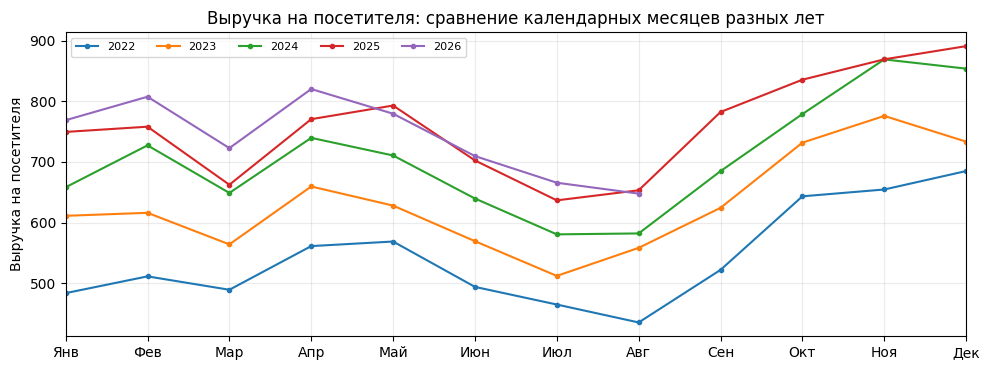

In [26]:
# --- Наложение линий разных годов на одну календарную ось ---
# Идея: одна линия = один год. По оси X — номер месяца (1..12), одинаковый
# для всех лет. Это позволяет сравнить сезонный профиль разных лет «в лоб»:
# например, декабрь-2024 против декабря-2025.
#
# assign создаёт копию DataFrame с новыми столбцами за один вызов:
#   Год           — год даты (2022, 2023, ...), нужен для groupby;
#   Номер_месяца  — номер месяца 1..12, используется как координата по X.
overlay = network.assign(Год=network["Месяц"].dt.year,
                         Номер_месяца=network["Месяц"].dt.month)

# Русские сокращения месяцев — для читаемых подписей на оси X.
# Список индексируется 0..11, но с помощью set_xticks(range(1,13), ...) мы
# сопоставляем элементу 1 (январь) первый элемент списка и т.д.
months_ru = ["Янв", "Фев", "Мар", "Апр", "Май", "Июн", "Июл", "Авг", "Сен", "Окт", "Ноя", "Дек"]

# Для каждой метрики — отдельный график, на нём по одной линии на год.
for metric in METRICS:
    # Создаём фигуру и ось. figsize=(10, 3.8) — широкий, но невысокий формат:
    # по X 12 месяцев, по Y один масштаб метрики.
    fig, ax = plt.subplots(figsize=(10, 3.8))

    # groupby("Год") даёт по одной группе на год, sort=True — по возрастанию лет.
    # Это важно: легенда и цвета будут идти в хронологическом порядке.
    for year, g in overlay.groupby("Год", sort=True):
        # Для конверсии домножаем на 100 (перевод доли в проценты),
        # для всех остальных метрик значения остаются в исходных единицах.
        # g[metric] — Series с индексом исходного DataFrame, но длина совпадает
        # с g["Номер_месяца"], поэтому обе серии можно передать в plot().
        values = g[metric] * (100 if metric == "Конверсия" else 1)
        ax.plot(g["Номер_месяца"], values, marker="o", markersize=3, label=str(year))

    # Подписи по X: 12 позиций 1..12 → русские сокращения месяцев.
    # Второй аргумент set_xticks — список подписей.
    ax.set_xticks(range(1,13), months_ru)

    # Жёстко ограничиваем ось X ровно 12 месяцами,
    # чтобы 2026 год (данные до августа) не «расширял» область графика.
    ax.set_xlim(1,12)

    # Подпись оси Y: к имени метрики добавляем ", %" только для конверсии.
    ax.set_ylabel(metric + (", %" if metric == "Конверсия" else ""))

    # Заголовок: имя метрики + пояснение, что это сравнение календарных месяцев.
    ax.set_title(f"{metric}: сравнение календарных месяцев разных лет")

    # Полупрозрачная сетка — не отвлекает, но помогает читать значения.
    ax.grid(alpha=0.25)

    # Легенда в 5 колонок: годов может быть до 5 (2022–2026), они помещаются в один ряд.
    # fontsize=8 — чтобы не занимала много места.
    ax.legend(ncol=5, fontsize=8)

    # Автоматически подгоняем отступы, чтобы подписи не обрезались.
    plt.tight_layout()

    # Показываем график (в Jupyter отображается сразу, в скрипте — блокирует до закрытия).
    plt.show()

**Как читать графики:** сравнивайте одинаковые месяцы разных лет по вертикали и форму линий по календарю. Повторение пиков в одном и том же месяце может указывать на сезонность; разный общий уровень линий — на тренд или иные изменения. Сам график не доказывает причину и статистическую значимость.

## 12Б. Графики взаимосвязанных KPI: совместная динамика и диаграммы рассеяния

Примеры пар: **Посетители–Конверсия**, **Длина чека–Конверсия**, **Длина чека–Средняя цена**, **Конверсия–Выручка на посетителя**. Мы проверим предположение об обратной связи, но не будем считать его заранее истинным.

Чтобы сравнить величины в разных единицах, на линейных графиках индексируем каждый ряд к **среднему значению 2022 года = 100**. Диаграммы рассеяния показывают исходные пары наблюдений; рядом выводим корреляции уровней и месячных изменений. Корреляция отражает совместные колебания, **не причинность**. Некоторые KPI содержат общие числители/знаменатели, из-за чего зависимость может быть частично математической.

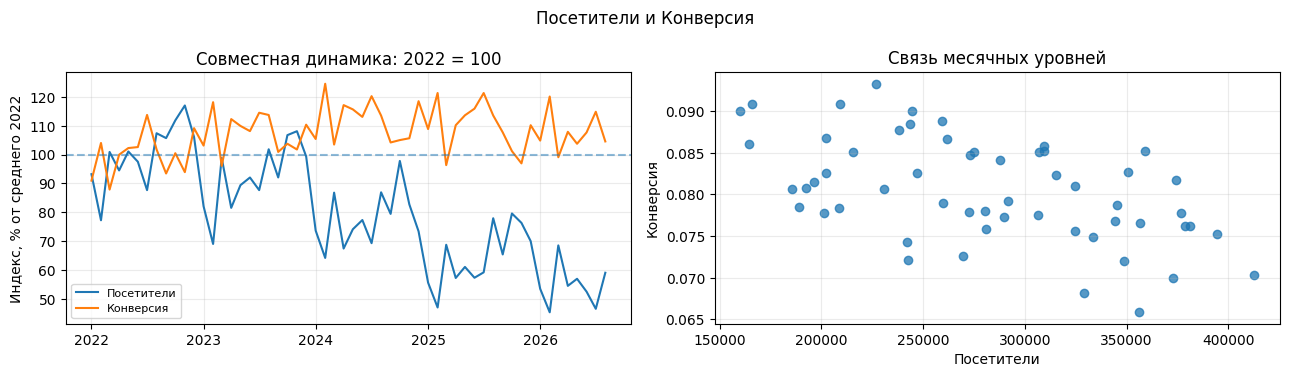

Посетители × Конверсия: r уровней = -0.528; r месячных изменений = -0.606


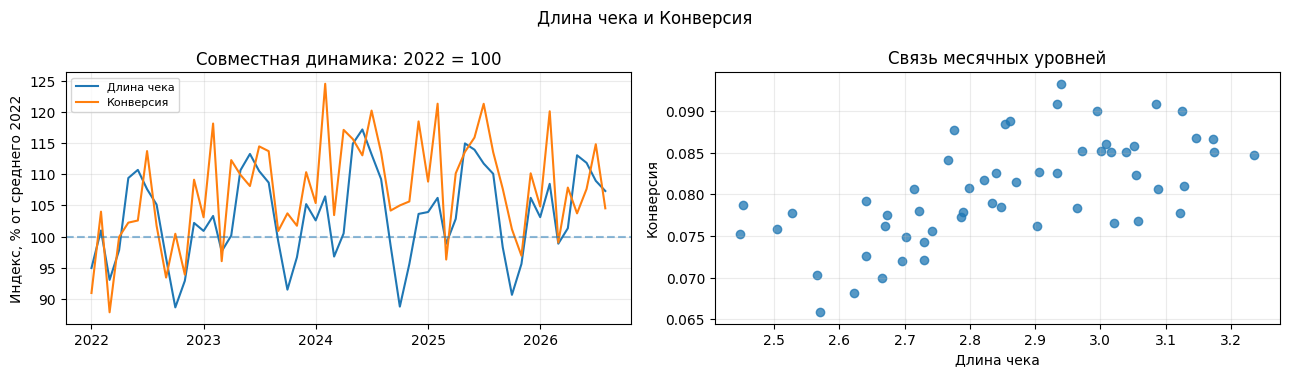

Длина чека × Конверсия: r уровней = +0.633; r месячных изменений = +0.519


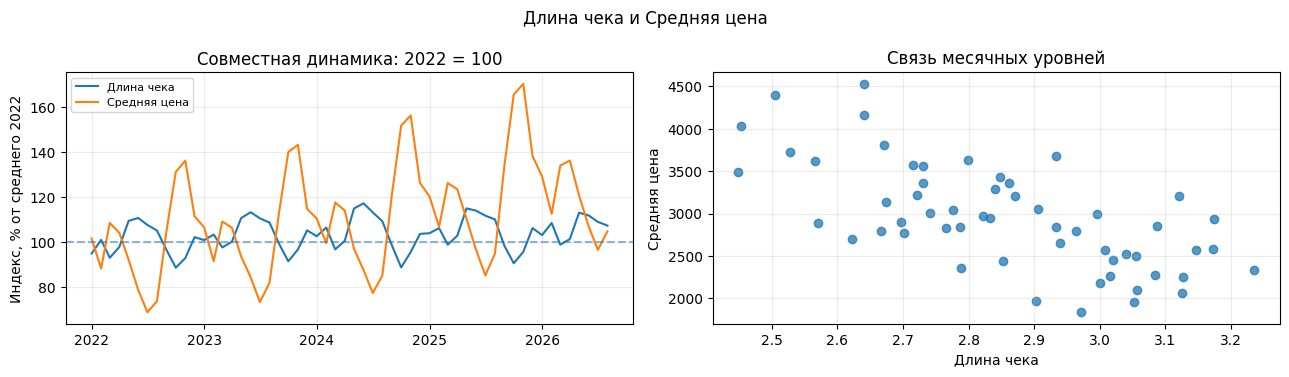

Длина чека × Средняя цена: r уровней = -0.671; r месячных изменений = -0.797


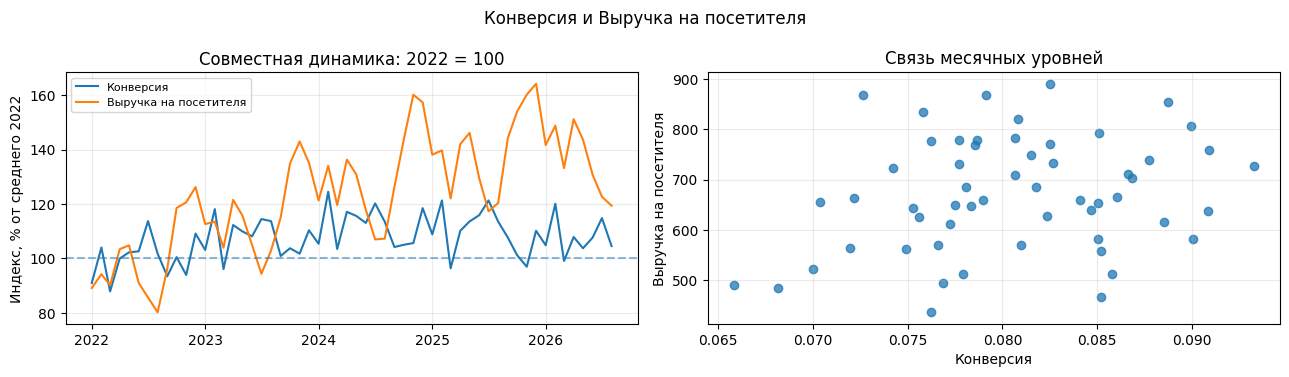

Конверсия × Выручка на посетителя: r уровней = +0.242; r месячных изменений = +0.362


In [27]:
# --- Пары метрик для сопоставления ---
# Идея: проверить, как связаны между собой некоторые KPI.
# Для каждой пары строим два графика:
#   1) совместная динамика (обе метрики, приведённые к сопоставимой шкале);
#   2) диаграмма рассеяния (каждая точка — месяц).
# И считаем две корреляции: по уровням и по месячным изменениям.
pairs = [
    ("Посетители", "Конверсия"),              # растёт ли конверсия при росте трафика?
    ("Длина чека", "Конверсия"),              # берут ли больше единиц за чек при той же конверсии?
    ("Длина чека", "Средняя цена"),           # есть ли trade-off «дороже → меньше штук»?
    ("Конверсия", "Выручка на посетителя"),   # вклад конверсии в денежную отдачу потока
]

# База для индексации: средние значения метрик за 2022 год.
# Каждый ряд дальше делится на эту базу и умножается на 100,
# чтобы обе метрики были в одной шкале (2022 = 100) — иначе на одном
# графике метрика с большими числами подавила бы метрику с малыми.
#
# loc по условию «год == 2022» берёт строки только за 2022-й;
# METRICS — все девять KPI, но нам понадобятся только left/right из pairs.
base_2022 = network.loc[network["Месяц"].dt.year == 2022, METRICS].mean()

# Перебираем пары и для каждой строим два графика и считаем корреляции.
for left, right in pairs:
    # Если база не положительна, индексация бессмысленна — пропускаем пару.
    # Отрицательная база дала бы «перевёрнутую» шкалу, а нулевая — деление на ноль.
    # В нашей сети все KPI положительны, но проверка — хорошая практика.
    if (base_2022[[left, right]] <= 0).any():
        print("Пропускаем индексацию из-за неположительной базы:", left, right)
        continue

    # Две оси рядом на одной фигуре: слева — совместная динамика,
    # справа — диаграмма рассеяния. figsize=(13, 3.8) — широкий формат
    # для двух подграфиков, но невысокий по вертикали.
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.8))

    # --- Левый график: совместная динамика, индексы к 2022 = 100 ---
    # Индексация к 100 устраняет разницу единиц (человек vs доля),
    # но НЕ убирает тренд и сезонность — обе метрики по-прежнему
    # содержат общие календарные колебания.
    ax1.plot(network["Месяц"], 100*network[left]/base_2022[left], label=left)
    ax1.plot(network["Месяц"], 100*network[right]/base_2022[right], label=right)

    # Горизонтальная линия на уровне 100 — «средний уровень 2022 года».
    # Всё, что выше, — выше среднего за 2022; ниже — соответственно ниже.
    ax1.axhline(100, linestyle="--", alpha=.5)

    ax1.set_title("Совместная динамика: 2022 = 100")
    ax1.set_ylabel("Индекс, % от среднего 2022")
    ax1.legend(fontsize=8)
    ax1.grid(alpha=.25)

    # --- Правый график: диаграмма рассеяния ---
    # Каждая точка — один месяц. По X — значения left, по Y — значения right.
    # По форме облака точек можно заподозрить наличие связи,
    # но точную меру дадим ниже через корреляции.
    ax2.scatter(network[left], network[right], alpha=.75)

    ax2.set_xlabel(left)
    ax2.set_ylabel(right)
    ax2.set_title("Связь месячных уровней")
    ax2.grid(alpha=.25)

    # Общий заголовок над двумя подграфиками.
    plt.suptitle(f"{left} и {right}")

    # Автоматическая подгонка отступов — чтобы заголовок и подписи не обрезались.
    plt.tight_layout()

    # Показ графика.
    plt.show()

    # --- Корреляции Пирсона ---
    # r_levels  — по уровням. Сильно завышена общим трендом и сезонностью:
    #             если обе метрики растут из-за сезонности, корреляция будет
    #             высокой даже при отсутствии прямой связи между ними.
    # r_changes — по месячным разностям (diff). Снимает часть общего тренда,
    #             но не устраняет автокорреляцию и не даёт причинности.
    #
    # network[[left, right]].corr() возвращает матрицу 2×2;
    # .iloc[0,1] берёт коэффициент вне диагонали.
    r_levels = network[[left,right]].corr().iloc[0,1]
    r_changes = network[[left,right]].diff().dropna().corr().iloc[0,1]

    # Печатаем оба коэффициента. Знак "+.3f" всегда показывает знак,
    # чтобы было видно направление связи.
    print(f"{left} × {right}: r уровней = {r_levels:+.3f}; r месячных изменений = {r_changes:+.3f}")

**Интерпретация:** если индексы расходятся, проверьте диаграмму рассеяния и корреляцию изменений, прежде чем говорить об обратной связи. Даже отрицательная корреляция не означает обратную **пропорциональность** (формулу вида $y=c/x$). Для фактических выводов понадобятся сопоставление внутри сезонов, учёт тренда и отдельная статистическая проверка. В частности, рост посетителей может снижать долю покупок при ограниченной пропускной способности, но данные могут показать и другую картину.

## 12В. Дополнительная проверка: соотношение посетителей и выручки на посетителя

Такой график иллюстрирует разницу между количеством входящего потока и его денежной результативностью. Он не показывает качество работы сотрудников без учёта ассортимента, цен и сезонности.

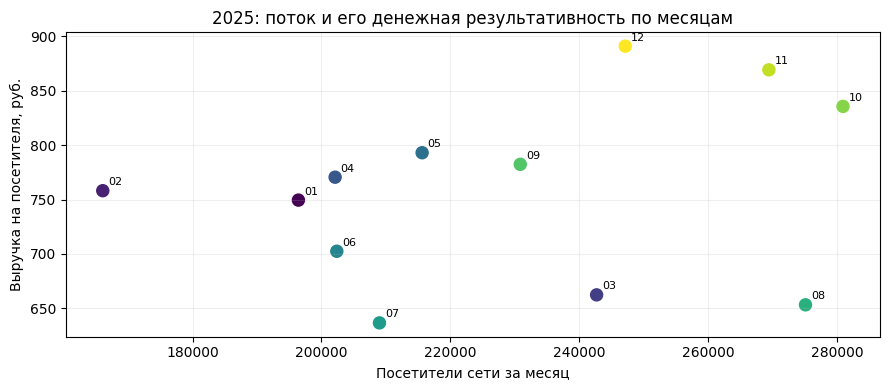

In [28]:
# --- Рассеяние по 2025 году: поток vs денежная результативность ---
# Идея: посмотреть, как связаны между собой два показателя месяца:
#   X — Посетители (сколько пришло людей);
#   Y — Выручка на посетителя (сколько денег принёс один человек).
# Каждая точка — один месяц 2025 года. Цвет кодирует номер месяца,
# чтобы сезонный контекст (например, декабрьский пик) был виден на графике.
#
# Берём только 2025 год: он полный (12 месяцев), что даёт 12 точек —
# достаточно, чтобы увидеть паттерн, и не слишком много, чтобы график
# оставался читаемым.
y25 = network[network["Месяц"].dt.year == 2025].copy()

# Создаём фигуру и ось. figsize=(9,4) — квадратный-ish формат,
# удобный для диаграммы рассеяния.
fig, ax = plt.subplots(figsize=(9,4))

# scatter — диаграмма рассеяния:
#   x = Посетители (месячный трафик сети),
#   y = Выручка на посетителя (руб./чел.),
#   c = номер месяца (1..12) — цвет каждой точки кодирует месяц,
#       что позволяет увидеть, как месяцы распределены по осям;
#   cmap = "viridis" — цветовая карта (жёлтый = высокие значения,
#       фиолетовый = низкие);
#   s = 75 — размер точек (в пунктах^2), достаточно крупный, чтобы
#       вместить подпись и быть заметным.
scatter = ax.scatter(y25["Посетители"], y25["Выручка на посетителя"],
                     c=y25["Месяц"].dt.month, cmap="viridis", s=75)

# Подписываем каждую точку номером месяца (01..12), смещая текст на пару пикселей.
# iterrows() даёт пары (index, row) — индекс нам не нужен, поэтому "_".
# strftime("%m") возвращает двузначный номер месяца ("01", ..., "12").
# xytext и textcoords="offset points" задают смещение текста относительно точки:
# без этого подпись наложилась бы на маркер.
for _, r in y25.iterrows():
    ax.annotate(r["Месяц"].strftime("%m"),
                (r["Посетители"],r["Выручка на посетителя"]),
                xytext=(4,4), textcoords="offset points", fontsize=8)

# Подписи осей: слева — что такое X, справа — что такое Y.
# Единицы измерения указываем явно (человек, руб.), чтобы график
# был самодостаточным.
ax.set_xlabel("Посетители сети за месяц")
ax.set_ylabel("Выручка на посетителя, руб.")

# Заголовок — коротко о содержании графика.
ax.set_title("2025: поток и его денежная результативность по месяцам")

# Лёгкая сетка: помогает сопоставлять точки по осям, не отвлекая внимание.
ax.grid(alpha=.2)

# Автоматическая подгонка отступов, чтобы подписи не обрезались.
plt.tight_layout()

# Показ графика.
plt.show()

## Что делает блок в целом
Строит одну диаграмму рассеяния для 2025 года, где каждая точка — месяц. По осям:

X — Посетители (трафик): сколько людей пришло в сеть за месяц.

Y — Выручка на посетителя: сколько денег в среднем принёс один посетитель.

Цвет — номер месяца: помогает увидеть, «куда» попадают разные сезоны.

Это разложение выручки на две независимые компоненты: объём потока и его денежная отдача. Цель — увидеть, есть ли между ними связь (положительная, отрицательная, отсутствует) и как она выглядит по сезонам.

## Как читать график
Облако точек вытянуто вправо-вверх — чем больше трафик, тем выше отдача. Это «здоровый» сценарий: рост потока не размывает качество.

Облако вытянуто вправо-вниз — с ростом трафика отдача падает. Возможная причина: в высокий сезон приходит «разогретая» публика, часть которой покупает меньше среднего; или ограниченная пропускная способность (очереди, нехватка персонала).

Облако без направления — метрики независимы, связь между ними слабая.

Цвета сгруппированы — например, все зимние месяцы в одном углу, летние в другом. Это признак сезонной структуры.

Отдельные точки-выбросы — стоит разбираться: аномальный месяц, разовая акция, ошибка в данных.

**Интерпретация:** каждая точка — месяц 2025 года; номер возле неё помогает определить календарный эффект. Увеличение потока не обязано сопровождаться ростом выручки на посетителя. Для анализа причин сравните конверсию, длину чека и среднюю цену в соответствующие месяцы.

# 13. Что такое сезонность?

**Сезонность** — это закономерно повторяющееся изменение показателя, связанное с календарным периодом.

Для fashion retail сезонность может быть связана с:

- погодой;
- сменой коллекций;
- праздничными периодами;
- распродажами;
- началом и окончанием fashion-сезона;
- покупательским поведением.

Важно отличать:

- **тренд** — долгосрочное направление изменения;
- **сезонность** — повторяющийся календарный рисунок;
- **случайные колебания** — изменения без устойчивой повторяемой структуры.

# 14. Месячные сезонные коэффициенты

Для первого знакомства используем простой описательный коэффициент:

$$
K_m=
\frac{\text{среднее значение KPI в месяце }m}
{\text{среднее значение KPI за все месяцы}}
$$

Интерпретация:

- \(K=1.15\) — месяц примерно на 15% выше среднего;
- \(K=0.82\) — примерно на 18% ниже среднего;
- \(K\approx1.00\) — близок к среднему уровню.

Чтобы все календарные месяцы имели одинаковое число наблюдений, для расчёта коэффициентов используем **полные 2022–2025 годы**.

Это пока упрощённая описательная оценка сезонности, а не полноценная декомпозиция временного ряда.

**Ограничение:** усреднение сырых уровней может смешивать сезонность с трендом; для продвинутого прогнозирования будем отдельно оценивать тренд и устойчивость коэффициентов по годам.


In [30]:
# --- Отбор полных годов ---
# 2026 год неполный (данные до августа), поэтому исключаем его,
# иначе средние по месяцам будут смещены.
full_years = network[
    network["Месяц"].dt.year.isin([2022, 2023, 2024, 2025])
].copy()

# Номер месяца 1..12 — удобный ключ группировки (сортируется естественно).
full_years["Номер месяца"] = full_years["Месяц"].dt.month

# Словарь для красивых подписей месяцев в индексе season_idx.
month_names = {
    1: "Янв", 2: "Фев", 3: "Мар", 4: "Апр",
    5: "Май", 6: "Июн", 7: "Июл", 8: "Авг",
    9: "Сен", 10: "Окт", 11: "Ноя", 12: "Дек"
}

# Средние значения метрик по каждому календарному месяцу (по 4 годам).
# Результат: 12 строк × N столбцов (метрик).
month_means = full_years.groupby("Номер месяца")[METRICS].mean()

# Общее среднее по всем месяцам и годам — база для индекса сезонности.
overall_means = full_years[METRICS].mean()

# Индекс сезонности: среднее по месяцу делится на общее среднее.
# axis=1 — деление идёт по строкам, каждое значение столбца
# делится на соответствующее значение из overall_means.
season_idx = month_means.div(overall_means, axis=1)

# Меняем индекс на человекочитаемые названия месяцев (1..12 → Янв..Дек).
season_idx.index = [month_names[m] for m in season_idx.index]

display(season_idx.round(3))

,Выручка,Посетители,Чеки,Покупки,Конверсия,Длина чека,Средняя цена,Средний чек,Выручка на посетителя
Янв,0.852,0.910,0.864,0.844,0.950,0.978,0.999,0.989,0.948
Фев,0.755,0.769,0.839,0.851,1.089,1.013,0.879,0.902,0.990
Мар,0.951,1.061,0.954,0.896,0.893,0.939,1.050,0.998,0.896
Апр,0.923,0.898,0.921,0.898,1.023,0.975,1.020,1.007,1.035
Май,0.987,0.973,1.002,1.094,1.027,1.093,0.895,0.990,1.023
Июн,0.874,0.968,0.992,1.098,1.023,1.106,0.791,0.885,0.911
Июл,0.752,0.908,0.997,1.074,1.093,1.076,0.694,0.756,0.831
Авг,0.942,1.117,1.157,1.219,1.030,1.052,0.764,0.815,0.844
Сен,1.003,1.023,0.968,0.925,0.946,0.954,1.077,1.040,0.990
Окт,1.345,1.183,1.141,0.999,0.955,0.874,1.338,1.183,1.133


## 15. У какого KPI сезонность выражена сильнее?

Для простого сравнения введём амплитуду сезонных коэффициентов:

$$
Amplitude=
K_{max}-K_{min}
$$

Чем больше диапазон между максимальным и минимальным сезонным коэффициентом, тем заметнее календарная сезонность показателя.

Это простая учебная мера, а не универсальный статистический тест сезонности.

**Что делает код:** для каждого KPI находит минимальный и максимальный месячный коэффициент и рассчитывает разницу между ними. Сортировка помогает увидеть показатели с самым широким сезонным диапазоном.

In [31]:
# --- Сводка силы сезонности ---
# .min() и .max() по умолчанию агрегируют по строкам (axis=0),
# то есть сворачивают 12 месяцев в одно значение на каждый столбец (метрику).
season_strength = pd.DataFrame({
    "Min_K": season_idx.min(),
    "Max_K": season_idx.max()
})

# Амплитуда — разница между самым высоким и самым низким сезонным коэффициентом.
# Мера безразмерная, поэтому метрики разных масштабов сравнимы между собой.
season_strength["Амплитуда"] = (
    season_strength["Max_K"] - season_strength["Min_K"]
)

# Сортируем: наверху — самые сезонные метрики, внизу — самые стабильные.
season_strength = season_strength.sort_values(
    "Амплитуда",
    ascending=False
)

display(season_strength.round(3))

,Min_K,Max_K,Амплитуда
Средняя цена,0.694,1.378,0.684
Выручка,0.752,1.372,0.621
Средний чек,0.756,1.290,0.534
Посетители,0.769,1.183,0.413
Покупки,0.844,1.219,0.375
Выручка на посетителя,0.831,1.201,0.369
Чеки,0.839,1.157,0.318
Длина чека,0.874,1.106,0.232
Конверсия,0.893,1.093,0.200


**Как интерпретировать:** больший диапазон означает сильнее выраженный профиль *в выбранной простой мере*. Это не статистический тест: выбросы и сдвиг уровня могут искажать сравнение.

**Что делает код:** строит горизонтальную диаграмму амплитуды коэффициентов для девяти KPI.

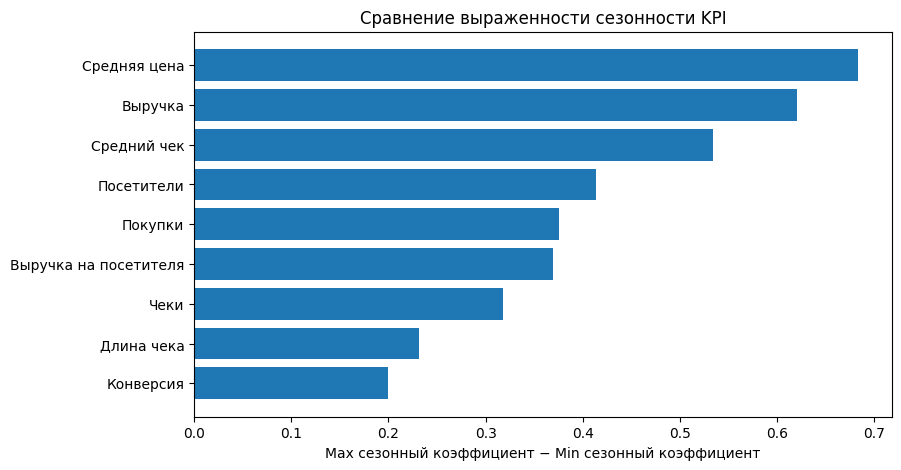

In [32]:
# --- Диаграмма амплитуд сезонности ---
# Берём индексы и значения в обратном порядке, чтобы самая "сезонная"
# метрика оказалась сверху (в barh первая строка рисуется внизу).
plt.figure(figsize=(9, 5))
plt.barh(
    season_strength.index[::-1],
    season_strength["Амплитуда"][::-1]
)
plt.xlabel("Max сезонный коэффициент − Min сезонный коэффициент")
plt.title("Сравнение выраженности сезонности KPI")
plt.show()

**Как интерпретировать:** длина столбца характеризует диапазон оценённых месячных коэффициентов, а не гарантированную сезонную силу и не причинную связь.

## 16. Графики месячных сезонных коэффициентов

**Что делает код:** последовательно строит для каждого KPI профиль двенадцати месячных коэффициентов с ориентиром 1,0.

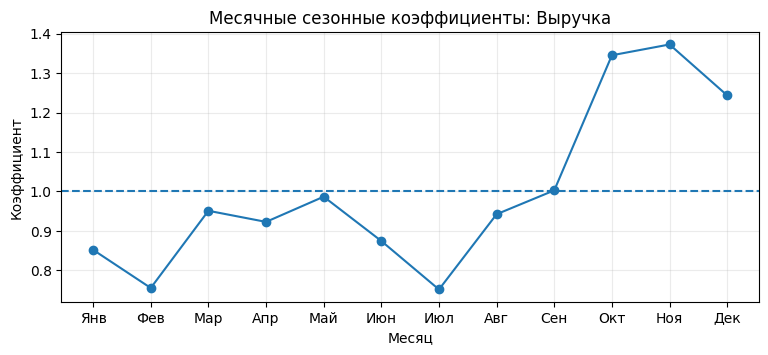

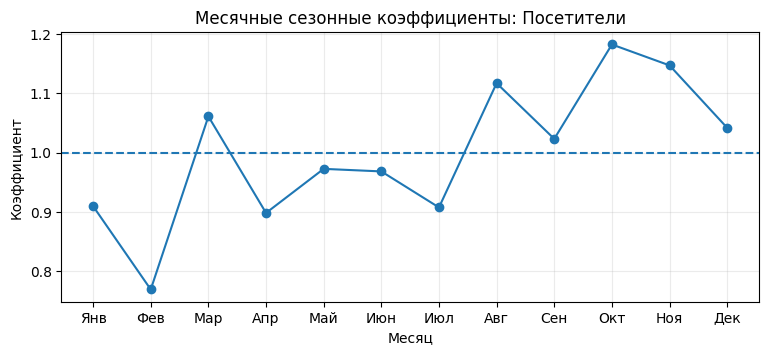

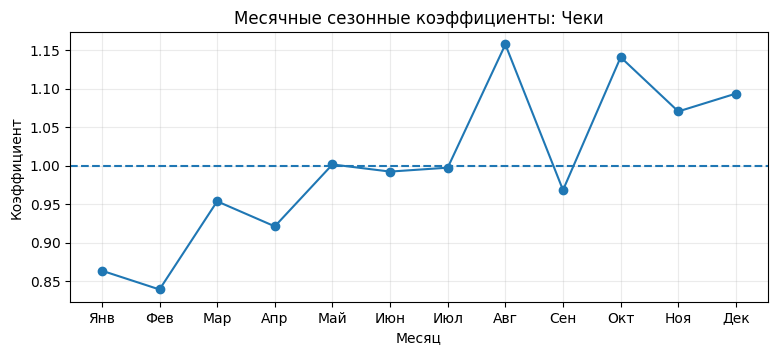

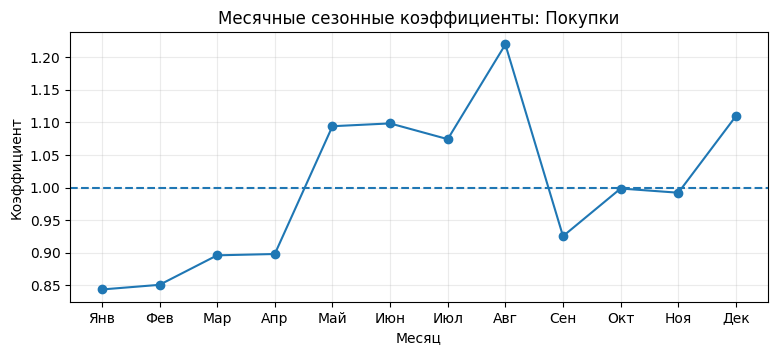

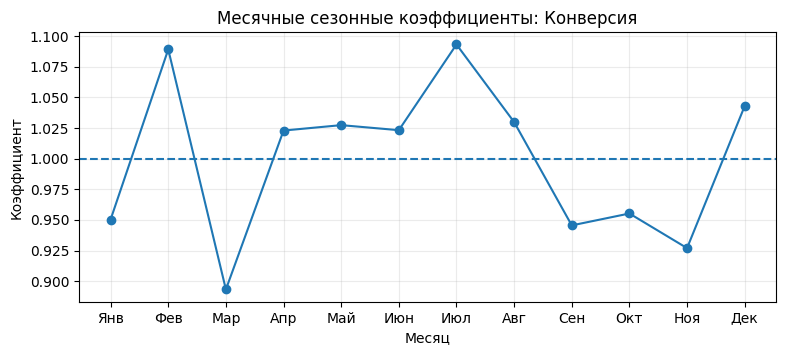

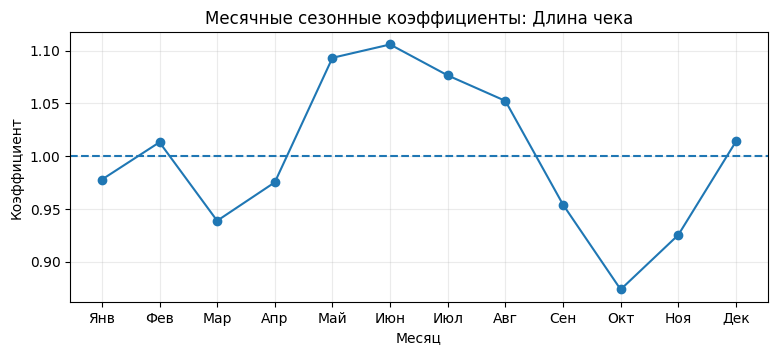

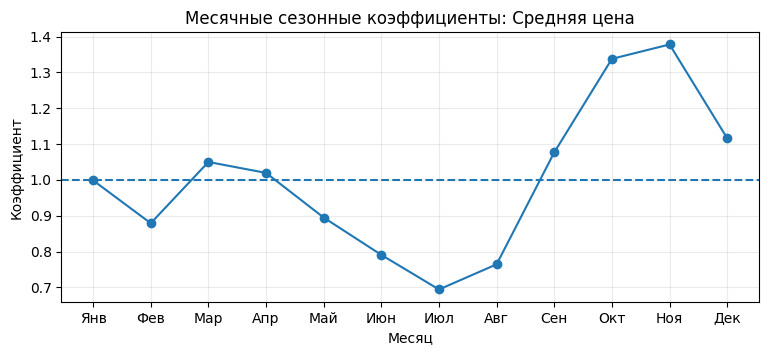

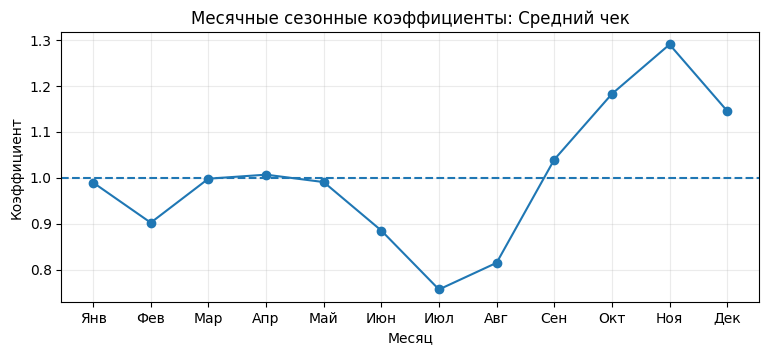

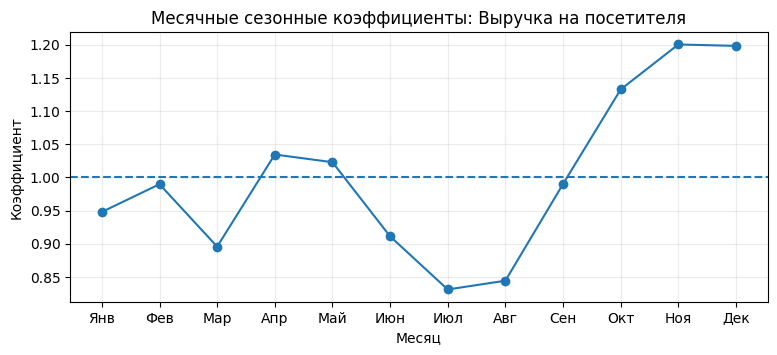

In [33]:
# --- Профили сезонности по каждому KPI ---
for metric in METRICS:
    plt.figure(figsize=(9, 3.5))
    plt.plot(
        season_idx.index,
        season_idx[metric],
        marker="o"
    )
    # Горизонтальная линия на уровне 1.0 — «средний месяц».
    plt.axhline(1, linestyle="--")
    plt.title(f"Месячные сезонные коэффициенты: {metric}")
    plt.ylabel("Коэффициент")
    plt.xlabel("Месяц")
    plt.grid(alpha=0.25)
    plt.show()

**Как интерпретировать:** значения выше 1 соответствуют месяцам выше среднего за выбранные годы; ищите устойчивые пики и провалы, а не сравнивайте абсолютные масштабы метрик.

### Вопросы для интерпретации

1. У какого показателя сезонность выражена особенно ярко?
2. Какие KPI наиболее стабильны по месяцам?
3. Совпадают ли сезонные пики выручки и посетителей?
4. Насколько сезонна средняя цена?
5. Может ли высокая вариативность выручки объясняться сезонностью?

Ответы нужно формулировать **по рассчитанным данным**, а не по общим представлениям о fashion retail.

# 17. Fashion-сезоны S и W

В розничной торговле одеждой календарный год не всегда является основным бизнес-периодом.

В нашем курсе используем:

### Сезон S
**март — август**

### Сезон W
**сентябрь — февраль**

Обозначение сезона:

- `S22` = март 2022 — август 2022;
- `W22` = сентябрь 2022 — февраль 2023;
- `S23` = март 2023 — август 2023;
- `W23` = сентябрь 2023 — февраль 2024;
- и т.д.

Таким образом, год W определяется по **сентябрю**, с которого начинается сезон.

**Что делает код:** присваивает каждому месяцу ярлык сезона по дате его начала; январь и февраль относятся к W предыдущего года.

In [34]:
# --- Определение fashion-сезона по дате ---
def fashion_season(date):
    """
    Возвращает ярлык сезона:
      S{yy} — март..август yy;
      W{yy} — сентябрь yy..февраль yy+1,
              при этом январь и февраль относятся к W предыдущего года.
    """
    year = date.year
    month = date.month

    if 3 <= month <= 8:
        return f"S{str(year)[-2:]}"         # март-август — S текущего года
    elif month >= 9:
        return f"W{str(year)[-2:]}"         # сентябрь-декабрь — W текущего года
    else:
        # Январь-февраль относятся к W, начавшемуся в предыдущем году.
        return f"W{str(year - 1)[-2:]}"

# Применяем к каждому месяцу сети — получаем столбец "Сезон".
network["Сезон"] = network["Месяц"].apply(fashion_season)

# Показываем первые 16 строк, чтобы убедиться в корректности перехода через январь.
display(network[["Месяц", "Сезон"]].head(16))

,Месяц,Сезон
0,2022-01-01,W21
1,2022-02-01,W21
2,2022-03-01,S22
3,2022-04-01,S22
4,2022-05-01,S22
5,2022-06-01,S22
6,2022-07-01,S22
7,2022-08-01,S22
8,2022-09-01,W22
9,2022-10-01,W22


**Как интерпретировать:** `W25` — сентябрь 2025 — февраль 2026, а `S26` — март — август 2026; это предотвращает ошибки при сравнении сезонов.

## 18. Полные и неполные сезоны

Наша база начинается в январе 2022 и заканчивается августом 2026.

Поэтому:

- `W21` представлен только январём–февралём 2022 — **неполный**, исключаем;
- `S22` — полный;
- `W22` — полный;
- ...
- `W25` — полный;
- `S26` — полный.

При сравнении сезонов используем только периоды, содержащие все 6 месяцев.

**Что делает код:** подсчитывает число доступных месяцев в каждом сезоне и оставляет только сезоны с шестью наблюдениями.

In [35]:
# --- Сколько месяцев в каждом сезоне ---
# nunique() считает число уникальных месяцев (обычно 6 для полного сезона).
season_month_count = (
    network.groupby("Сезон")["Месяц"]
    .nunique()
    .sort_index()
)

display(season_month_count.to_frame("Количество месяцев"))

# Оставляем только полные сезоны (ровно 6 месяцев) — их будем сравнивать.
full_seasons = season_month_count[
    season_month_count == 6
].index.tolist()

print("Полные сезоны:", full_seasons)

,Количество месяцев
Сезон,
S22,6
S23,6
S24,6
S25,6
S26,6
W21,2
W22,6
W23,6
W24,6


Полные сезоны: ['S22', 'S23', 'S24', 'S25', 'S26', 'W22', 'W23', 'W24', 'W25']


**Как интерпретировать:** незавершённый `W21` нельзя ставить в один ряд с полными S/W без отдельной нормировки и пометки о неполноте.

# 19. Правильный расчёт KPI по сезонам

Здесь снова важно не брать простое среднее месячных относительных KPI.

Сначала суммируем:

- выручку;
- посетителей;
- чеки;
- покупки.

Затем заново рассчитываем:

- конверсию;
- длину чека;
- среднюю цену;
- средний чек;
- выручку на посетителя.

**Что делает код:** суммирует четыре абсолютные метрики по каждому полному сезону и заново рассчитывает пять относительных KPI.

In [36]:
# --- Агрегация абсолютных KPI по полным сезонам ---
# Снова правило: суммируем числители и знаменатели, а не средние отношений.
season_base = (
    network[network["Сезон"].isin(full_seasons)]   # только полные сезоны
    .groupby("Сезон", as_index=False)
    .agg(
        Выручка=("Выручка", "sum"),
        Посетители=("Посетители", "sum"),
        Чеки=("Чеки", "sum"),
        Покупки=("Покупки", "sum")
    )
)

# --- Пересчёт относительных KPI за сезон ---
season_base["Конверсия"] = (
    season_base["Чеки"] / season_base["Посетители"]
)
season_base["Длина чека"] = (
    season_base["Покупки"] / season_base["Чеки"]
)
season_base["Средняя цена"] = (
    season_base["Выручка"] / season_base["Покупки"]
)
season_base["Средний чек"] = (
    season_base["Выручка"] / season_base["Чеки"]
)
season_base["Выручка на посетителя"] = (
    season_base["Выручка"] / season_base["Посетители"]
)

display(season_base)

,Сезон,Выручка,Посетители,Чеки,Покупки,Конверсия,Длина чека,Средняя цена,Средний чек,Выручка на посетителя
0,S22,1042735383,2078551,157425,453321,0.075738,2.879600,2300.214160,6623.696255,501.664565
1,S23,1128513143,1945589,158742,469152,0.081591,2.955437,2405.431807,7109.102462,580.036762
2,S24,1055855866,1630265,138517,415701,0.084966,3.001083,2539.940645,7622.572435,647.659041
3,S25,942345702,1346852,112502,338439,0.083530,3.008293,2784.388625,8376.257329,699.665369
4,S26,865572833,1193847,94567,278485,0.079212,2.944843,3108.148852,9153.011442,725.028277
5,W22,1302180957,2088010,159401,427142,0.076341,2.679670,3048.590298,8169.214478,623.646897
6,W23,1367349244,1920009,153543,423443,0.079970,2.757814,3229.122323,8905.318015,712.157726
7,W24,1208830690,1538943,126238,343200,0.082029,2.718674,3522.233945,9575.806730,785.494128
8,W25,1144219019,1377319,109126,300809,0.079231,2.756529,3803.805800,10485.301569,830.758175


**Как интерпретировать:** показатели отвечают на вопрос об итогах сезона; это не простые средние месячных конверсий, цен и чеков.

# 20. Сравниваем S только с S, W только с W

Для fashion retail корректнее оценивать динамику:

$$
S23 \; vs \; S22
$$

$$
S24 \; vs \; S23
$$

и отдельно:

$$
W23 \; vs \; W22
$$

$$
W24 \; vs \; W23
$$

Сравнение S с W отвечает уже на другой вопрос — о различии сезонной структуры бизнеса.

**Что делает код:** отделяет S от W, сортирует сезоны по годам и рассчитывает год-к-году изменение каждого KPI только внутри одного типа сезона.

In [37]:
# --- Динамика S к S и W к W ---
season_dynamics = season_base.copy()

# "Тип" — первая буква сезона (S или W); "Год" — две последние цифры.
season_dynamics["Тип"] = season_dynamics["Сезон"].str[0]
season_dynamics["Год"] = season_dynamics["Сезон"].str[1:].astype(int)

# Сортируем по типу и году: pct_change() должен сравнивать соседние годы внутри одного типа.
season_dynamics = season_dynamics.sort_values(["Тип", "Год"])

# Для каждой метрики считаем год-к-году изменение в % ВНУТРИ одного типа сезона.
# groupby("Тип") гарантирует, что S не сравнивается с W.
for metric in METRICS:
    season_dynamics[f"{metric}_YoY_%"] = (
        season_dynamics
        .groupby("Тип")[metric]
        .pct_change() * 100
    )

# Показываем выручку, посетителей, конверсию и среднюю цену с их YoY-изменениями.
display(
    season_dynamics[
        [
            "Сезон",
            "Выручка",
            "Выручка_YoY_%",
            "Посетители",
            "Посетители_YoY_%",
            "Конверсия",
            "Конверсия_YoY_%",
            "Средняя цена",
            "Средняя цена_YoY_%"
        ]
    ].round(3)
)

,Сезон,Выручка,Выручка_YoY_%,Посетители,Посетители_YoY_%,Конверсия,Конверсия_YoY_%,Средняя цена,Средняя цена_YoY_%
0,S22,1042735383,NaN,2078551,NaN,0.076,NaN,2300.214,NaN
1,S23,1128513143,8.226,1945589,-6.397,0.082,7.728,2405.432,4.574
2,S24,1055855866,-6.438,1630265,-16.207,0.085,4.137,2539.941,5.592
3,S25,942345702,-10.751,1346852,-17.384,0.084,-1.690,2784.389,9.624
4,S26,865572833,-8.147,1193847,-11.360,0.079,-5.169,3108.149,11.628
5,W22,1302180957,NaN,2088010,NaN,0.076,NaN,3048.590,NaN
6,W23,1367349244,5.005,1920009,-8.046,0.080,4.753,3229.122,5.922
7,W24,1208830690,-11.593,1538943,-19.847,0.082,2.575,3522.234,9.077
8,W25,1144219019,-5.345,1377319,-10.502,0.079,-3.411,3803.806,7.994


**Как интерпретировать:** первая доступная запись каждого типа не имеет предыдущей базы и остаётся пустой; относительные изменения конверсии не следует путать с изменением в процентных пунктах.

## 21. Визуальная динамика S и W

**Что делает код:** строит две линии по каждому показателю: S по годам и W по годам начала сезона.

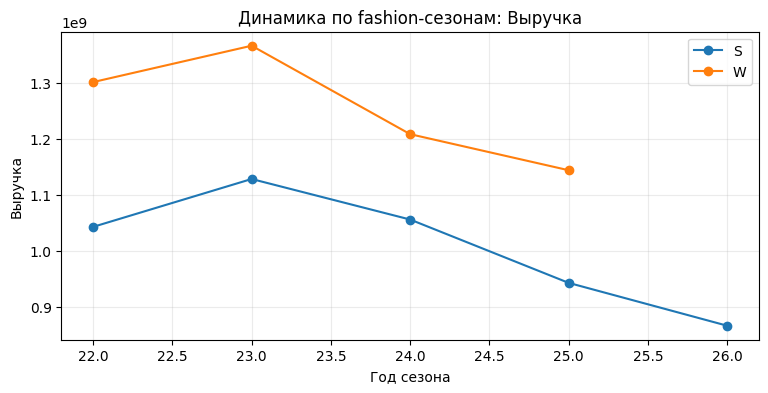

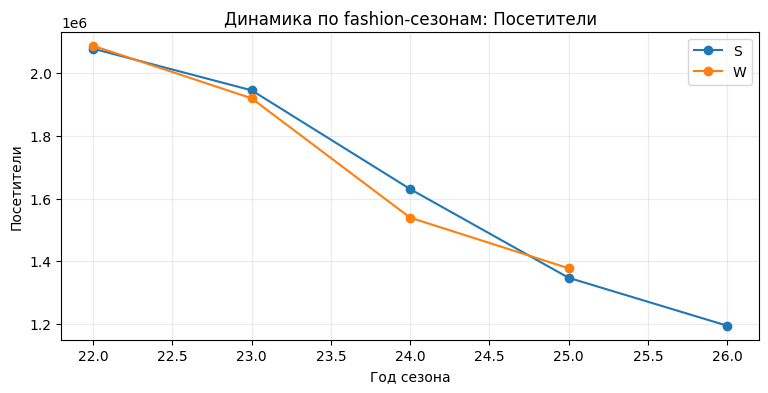

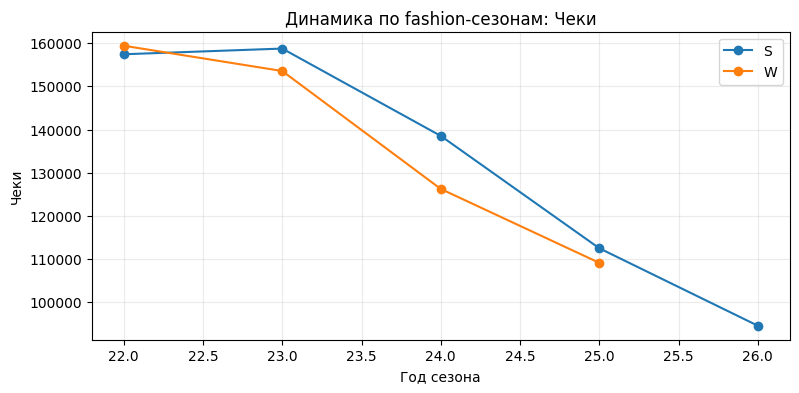

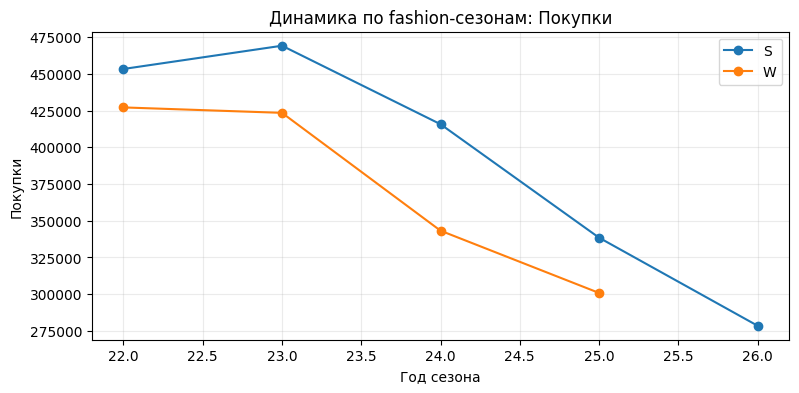

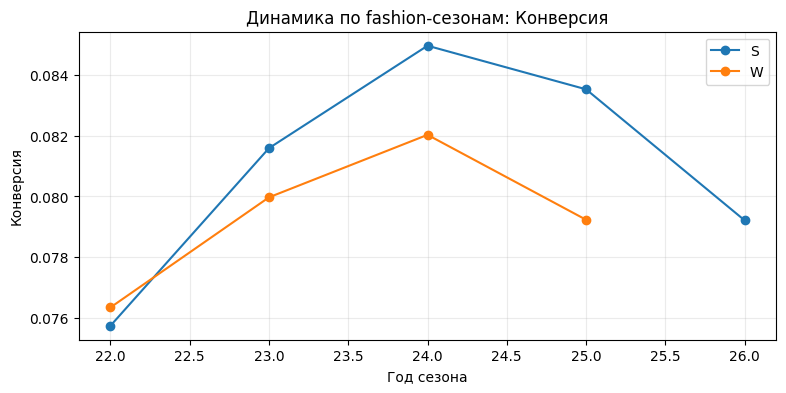

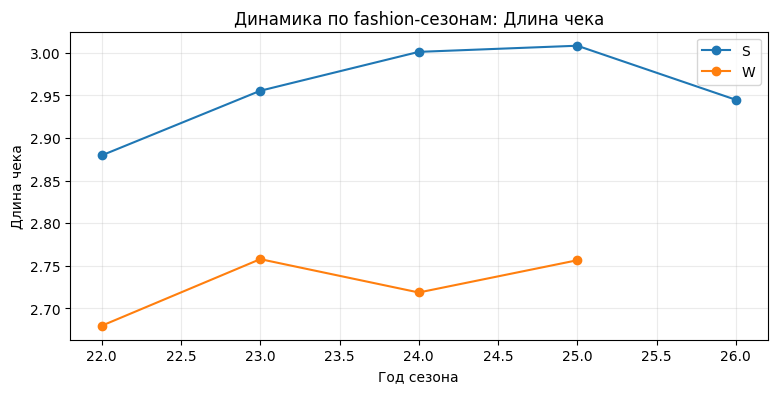

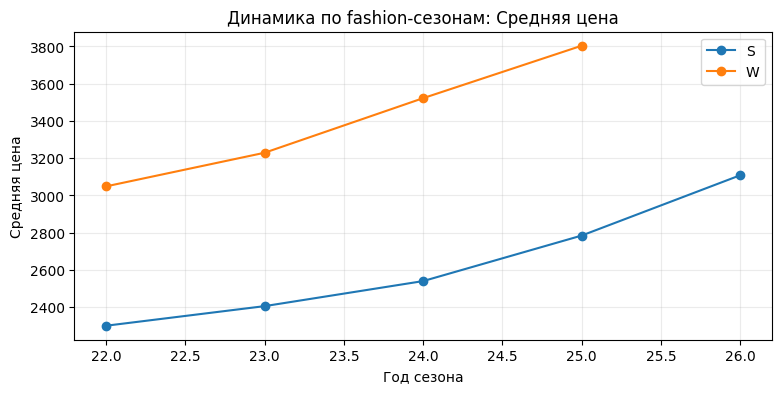

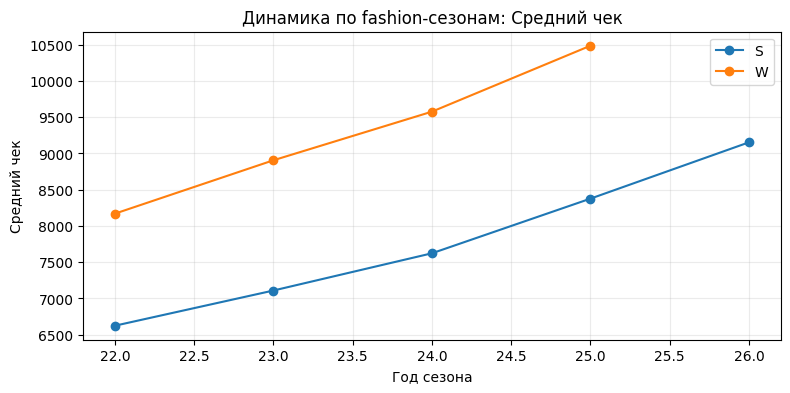

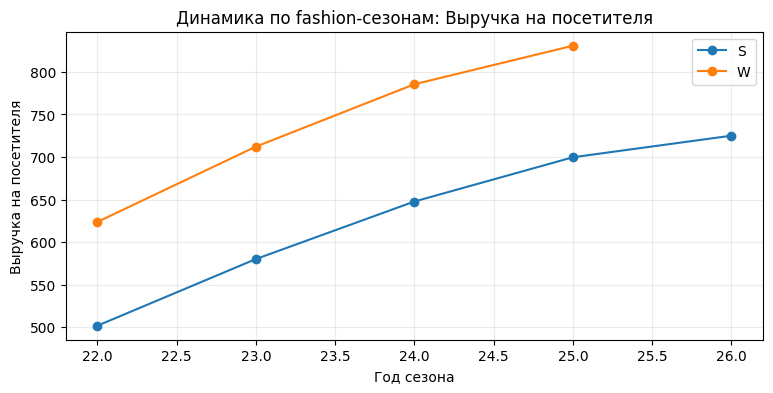

In [38]:
# --- Две линии на графике: S по годам и W по годам ---
for metric in METRICS:
    temp = season_dynamics.copy()

    plt.figure(figsize=(9, 4))

    # Для каждого типа сезона — отдельная линия по оси "Год".
    for season_type in ["S", "W"]:
        part = temp[temp["Тип"] == season_type]
        plt.plot(
            part["Год"],
            part[metric],
            marker="o",
            label=season_type
        )

    plt.title(f"Динамика по fashion-сезонам: {metric}")
    plt.xlabel("Год сезона")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

**Как интерпретировать:** расстояние между линиями описывает различие типов сезонов; наклон в пределах одной линии показывает динамику сопоставимых сезонов.

# 22. Доли S и W в полном fashion-цикле

Fashion-цикл будем определять как:

$$
S_{yy}+W_{yy}
$$

Например:

$$
S22 + W22
$$

соответствует периоду:

**март 2022 — февраль 2023**.

Рассчитаем доли S и W:

- в выручке;
- в посетителях.

Это позволит увидеть, одинаково ли сезоны формируют поток посетителей и денежный результат.

**Что делает код:** объединяет S и W с одинаковым годом начала в единый fashion-цикл и вычисляет долю каждого сезона отдельно по выручке и посетителям.

In [39]:
# --- Доли S и W в fashion-цикле ---
cycle = season_base.copy()
cycle["Тип"] = cycle["Сезон"].str[0]
cycle["Год"] = cycle["Сезон"].str[1:].astype(int)

# pivot: строки = годы, столбцы — мультииндекс (метрика, тип сезона).
# Получаем таблицу, где для каждого года рядом стоят S и W по выручке и посетителям.
cycle_pivot = cycle.pivot(
    index="Год",
    columns="Тип",
    values=["Выручка", "Посетители"]
)

# Оставляем только годы, где есть и S, и W (иначе доли не посчитать).
cycle_pivot = cycle_pivot.dropna()

result_cycle = pd.DataFrame(index=cycle_pivot.index)

# --- Доли по выручке ---
result_cycle["S_Выручка"] = cycle_pivot[("Выручка", "S")]
result_cycle["W_Выручка"] = cycle_pivot[("Выручка", "W")]
result_cycle["Доля_S_выручка"] = (
    result_cycle["S_Выручка"]
    / (result_cycle["S_Выручка"] + result_cycle["W_Выручка"])
)
result_cycle["Доля_W_выручка"] = 1 - result_cycle["Доля_S_выручка"]  # дополнение до 1

# --- Доли по посетителям ---
result_cycle["S_Посетители"] = cycle_pivot[("Посетители", "S")]
result_cycle["W_Посетители"] = cycle_pivot[("Посетители", "W")]
result_cycle["Доля_S_посетители"] = (
    result_cycle["S_Посетители"]
    / (result_cycle["S_Посетители"] + result_cycle["W_Посетители"])
)
result_cycle["Доля_W_посетители"] = 1 - result_cycle["Доля_S_посетители"]

# Переименовываем индекс из числа в строку вида "S22 + W22".
result_cycle.index = [
    f"S{str(y).zfill(2)} + W{str(y).zfill(2)}"
    for y in result_cycle.index
]

display(result_cycle.round(4))

,S_Выручка,W_Выручка,Доля_S_выручка,Доля_W_выручка,S_Посетители,W_Посетители,Доля_S_посетители,Доля_W_посетители
S22 + W22,1.042735e+09,1.302181e+09,0.4447,0.5553,2078551.0,2088010.0,0.4989,0.5011
S23 + W23,1.128513e+09,1.367349e+09,0.4522,0.5478,1945589.0,1920009.0,0.5033,0.4967
S24 + W24,1.055856e+09,1.208831e+09,0.4662,0.5338,1630265.0,1538943.0,0.5144,0.4856
S25 + W25,9.423457e+08,1.144219e+09,0.4516,0.5484,1346852.0,1377319.0,0.4944,0.5056


**Как интерпретировать:** доли S и W в каждом цикле должны суммироваться до 100%. Если доля выручки S выше доли посетителей S, стоит исследовать выручку на посетителя.

**Что делает код:** строит парные столбцы долей летнего сезона в выручке и посетительском потоке для завершённых fashion-циклов.

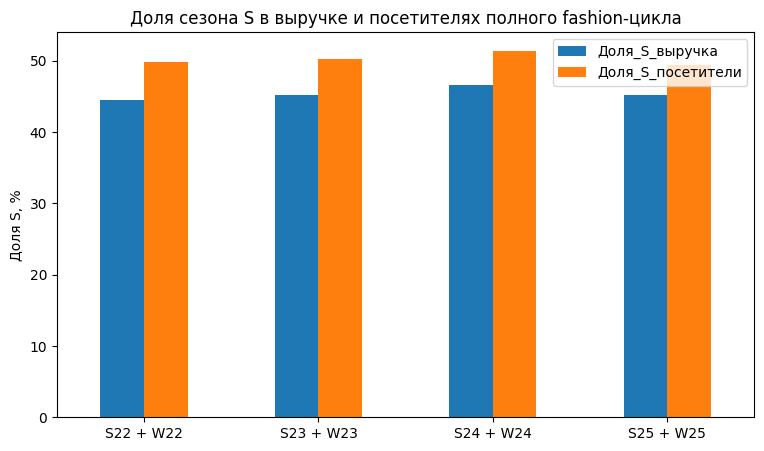

In [40]:
# --- Парные столбцы: доля S в выручке и в посетителях по циклам ---
# Умножаем на 100, чтобы вывести проценты, а не доли.
plot_share = result_cycle[
    [
        "Доля_S_выручка",
        "Доля_S_посетители"
    ]
] * 100

plot_share.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel("Доля S, %")
plt.title("Доля сезона S в выручке и посетителях полного fashion-цикла")
plt.xticks(rotation=0)
plt.show()

**Как интерпретировать:** разница столбцов показывает структуру, а не сама по себе объясняет эффективность или причину изменений. Сопоставьте выручку на посетителя и остальные KPI.

## 23. Как интерпретировать различие долей?

Предположим:

$$
Доля_S^{Revenue}
>
Доля_S^{Visitors}
$$

Это означает, что сезон S формирует большую долю выручки, чем его доля в потоке посетителей.

Одна из возможных причин — более высокая:

$$
\text{Выручка на посетителя}
$$

Но затем этот показатель необходимо разложить:

$$
\text{Выручка на посетителя}
=
\text{Конверсия}
\times
\text{Длина чека}
\times
\text{Средняя цена}
$$

Так мы переходим от простого описания к **факторному мышлению**.

# Дополнение. Ранг, процентный ранг и взвешенная оценка магазина

**Это отдельный учебный пример, выходящий за рамки анализа сети в целом.** Все предыдущие расчёты относятся к сети; теперь на коротком примере покажем, как сравнивать магазины друг с другом.

**Ранг** — место наблюдения в упорядоченном списке. Он зависит от числа объектов и способа обработки равенств. **Процентный ранг** переводит положение показателя на шкалу от 0 до 1. Удобно использовать его для сравнения разных KPI, но он **не устраняет** субъективность выбора показателей и весов.

Для учебного скоринга используем сопоставимый период **январь–август 2025** и четыре метрики: конверсию, длину чека, среднюю цену и выручку на посетителя. Это пример **заранее заданного управленческого приоритета**, а не объективный рейтинг качества магазинов. Высокая цена сама по себе не обязательно означает лучшую работу; поэтому в итоговый индекс вместо цены включаем **выручку на посетителя**, а остальную тройку используем для диагностики. В индексе учитываем конверсию, длину чека и выручку на посетителя. Последний показатель математически зависит от первых двух, так что он получает повышенный косвенный вес — это необходимо оговаривать и при необходимости менять набор KPI.

In [41]:
# --- Отдельный учебный кейс: сопоставление магазинов за один период ---
# Берём январь–август 2025 (сопоставимый отрезок для всех магазинов).
period_store = df[(df["Месяц"].dt.year == 2025) & (df["Месяц"].dt.month <= 8)]

# Агрегируем абсолютные KPI по каждому магазину.
store = (period_store.groupby("Магазин", as_index=False)
         .agg(Выручка=("Выручка", "sum"), Посетители=("Посетители", "sum"),
              Чеки=("Чеки", "sum"), Покупки=("Покупок", "sum")))

# Оставляем только магазины со всеми положительными знаменателями,
# чтобы избежать деления на ноль и NaN в относительных KPI.
store = store.query("Посетители > 0 and Чеки > 0 and Покупки > 0").copy()

# Пересчёт относительных KPI по каждому магазину.
store["Конверсия"] = store["Чеки"] / store["Посетители"]
store["Длина чека"] = store["Покупки"] / store["Чеки"]
store["Средняя цена"] = store["Выручка"] / store["Покупки"]
store["Выручка на посетителя"] = store["Выручка"] / store["Посетители"]

# Ранги: 1 — лучшее (наибольшее) значение; равенства получают средний ранг.
for metric in ["Конверсия", "Длина чека", "Средняя цена", "Выручка на посетителя"]:
    store[f"Ранг: {metric}"] = store[metric].rank(ascending=False, method="average")

# Процентный ранг 0..1: чем больше значение, тем ближе к 1.
# rank(ascending=True) — маленькое значение получает меньший ранг;
# вычитаем 1 и делим на n-1, чтобы получить долю от 0 до 1.
n = len(store)
for metric in ["Конверсия", "Длина чека", "Выручка на посетителя"]:
    store[f"P-rank: {metric}"] = store[metric].rank(ascending=True, method="average").sub(1).div(n-1)

# Веса — управленческое допущение (не объективная истина). Сумма должна быть 1.
weights = {"Конверсия":0.40, "Длина чека":0.20, "Выручка на посетителя":0.40}
assert np.isclose(sum(weights.values()), 1.0)

# Взвешенный индекс = сумма P-rank × вес. Лежит в диапазоне 0..1.
store["Учебный индекс"] = sum(store[f"P-rank: {m}"]*w for m,w in weights.items())

# Итоговое место: 1 — самый высокий индекс; при равенствах — минимальный номер.
store["Итоговое место"] = store["Учебный индекс"].rank(ascending=False,method="min").astype(int)

# Топ-10 магазинов по учебному индексу.
columns = ["Магазин", "Конверсия", "Длина чека", "Средняя цена",
           "Выручка на посетителя", "Учебный индекс", "Итоговое место"]
display(store.sort_values("Учебный индекс", ascending=False)[columns].head(10).round(3))

,Магазин,Конверсия,Длина чека,Средняя цена,Выручка на посетителя,Учебный индекс,Итоговое место
20,Магазин28,0.143,3.471,3083.130,1531.123,0.996,1
40,Магазин46,0.112,3.315,3125.079,1164.968,0.947,2
35,Магазин41,0.101,4.029,3281.541,1338.935,0.935,3
28,Магазин35,0.100,3.244,2708.101,882.591,0.820,4
43,Магазин49,0.099,3.222,2865.240,916.611,0.808,5
10,Магазин19,0.111,2.760,3145.271,966.394,0.796,6
18,Магазин26,0.092,3.390,3034.449,943.782,0.771,7
3,Магазин12,0.094,3.119,3366.161,989.195,0.751,8
47,Магазин7,0.101,2.729,3235.335,895.973,0.731,9
2,Магазин11,0.097,3.219,2742.193,855.200,0.722,10


**Интерпретация:** «учебный индекс» лежит в диапазоне 0–1 и позволяет сравнить **относительное положение** магазинов по выбранным показателям и весам, но не является оценкой их абсолютной рентабельности, работы продавцов или причин отличий. Меняя веса, можно получить другую последовательность мест. Процентный ранг, рассчитанный через `rank`, похож по смыслу на `ПРОЦЕНТРАНГ.ВКЛ`, но при совпадающих значениях/интерполяции может отличаться от точного алгоритма Excel.

In [42]:
# --- Проверка чувствительности: другой набор весов ---
# Увеличиваем вес выручки на посетителя — посмотрим, как переставятся магазины.
weights_alt = {"Конверсия":0.20, "Длина чека":0.20, "Выручка на посетителя":0.60}

# Считаем альтернативный индекс и место по нему.
store["Индекс (альтернативные веса)"] = sum(store[f"P-rank: {m}"]*w for m,w in weights_alt.items())
store["Место (альтернативные веса)"] = store["Индекс (альтернативные веса)"].rank(ascending=False,method="min").astype(int)

# Сравниваем два рейтинга: считаем изменение места (положительное — ухудшение).
comparison = store[["Магазин", "Итоговое место", "Место (альтернативные веса)"]].copy()
comparison["Изменение места"] = comparison["Место (альтернативные веса)"] - comparison["Итоговое место"]

# Сортируем по модулю изменения места — сверху те, кто сдвинулся сильнее всего.
display(comparison.sort_values("Изменение места", key=lambda s:s.abs(),ascending=False).head(10))

# Сколько магазинов вообще поменяли место при смене весов.
print("Магазинов со сменой места:", (comparison["Изменение места"]!=0).sum())

,Магазин,Итоговое место,Место (альтернативные веса),Изменение места
36,Магазин42,12,19,7
49,Магазин9,13,8,-5
41,Магазин47,14,10,-4
31,Магазин38,11,15,4
16,Магазин24,19,16,-3
47,Магазин7,9,12,3
45,Магазин50,16,13,-3
10,Магазин19,6,9,3
18,Магазин26,7,4,-3
44,Магазин5,36,34,-2


Магазинов со сменой места: 34


**Интерпретация:** изменение весов может переставить магазины местами даже при неизменных исходных данных. В управленческом отчёте веса и правила рейтинга необходимо фиксировать заранее и показывать анализ чувствительности. Для более корректной оценки работы следует также учитывать формат, размер и сезонность магазина.

# 24. Что мы пока сознательно НЕ делаем

В этом уроке мы не применяем:

- t-тест;
- Mann–Whitney;
- Wilcoxon;
- ANOVA;
- p-value;
- доверительные интервалы;
- формальные тесты сезонности;
- декомпозицию временного ряда;
- прогнозирование.

Сначала нужно научиться правильно рассчитывать и описывать показатели.

Статистический вывод начнётся в следующих уроках.

# 25. Итоги урока

После урока необходимо уметь объяснить:

### 1. Какие KPI можно суммировать
- Выручка
- Посетители
- Чеки
- Покупки

### 2. Какие KPI нужно пересчитывать
- Конверсия
- Длина чека
- Средняя цена
- Средний чек
- Выручка на посетителя

### 3. Различие между
- средним;
- взвешенным средним;
- медианой.

### 4. Что характеризуют
- дисперсия;
- стандартное отклонение;
- коэффициент вариации.

### 5. Почему нельзя анализировать вариативность без учёта сезонности.

### 6. Как рассчитываются простые месячные коэффициенты сезонности.

### 7. Как в fashion retail определяются сезоны
- S: март–август;
- W: сентябрь–февраль.

### 8. Почему S нужно сравнивать с S, а W — с W.

### 9. Как связаны основные KPI:

$$
\text{Выручка}
=
\text{Посетители}
\times
\text{Конверсия}
\times
\text{Длина чека}
\times
\text{Средняя цена}
$$

# 26. Практическое задание

Используя книгу `Retail_50_Stores_Synthetic_v1.xlsx`:

### Часть 1. Агрегация KPI
1. Получите месячные показатели всей сети.
2. Рассчитайте 9 основных KPI.
3. Проверьте формулы расчётных показателей.

### Часть 2. Описательная статистика
4. Для каждого KPI рассчитайте:
   - среднее;
   - медиану;
   - дисперсию;
   - стандартное отклонение;
   - коэффициент вариации.
5. Определите, какие показатели наиболее изменчивы.

### Часть 3. Сезонность
6. Постройте месячную динамику каждого KPI.
7. Рассчитайте сезонные коэффициенты по полным 2022–2025 годам.
8. Определите KPI с наиболее и наименее выраженной сезонностью.

### Часть 4. Fashion-сезоны
9. Сформируйте сезоны S и W.
10. Рассчитайте все 9 KPI по каждому полному сезону.
11. Рассчитайте динамику S/S и W/W.
12. Рассчитайте доли S и W в:
   - выручке;
   - посетителях.
13. Объясните различия между долями выручки и посетителей через показатель «Выручка на посетителя».

### Финальный вопрос
Какой из девяти KPI вы считаете наиболее полезным для интегральной оценки эффективности посетительского потока и почему?

### Дополнительное задание
14. Рассчитайте гармоническую среднюю цену при равных суммах выручки и объясните роль весов.
15. Рассчитайте геометрический среднегодовой темп выручки 2022–2025.
16. Найдите Q1, медиану, Q3 и P90 месячной выручки.
17. По наложенным графикам годов выделите два KPI с наиболее заметным сезонным рисунком.
18. Сравните диаграммы рассеяния «Посетители–Конверсия» и «Длина чека–Конверсия»: одинаково ли направление связи?
19. Проверьте, как меняется учебный рейтинг магазинов при других весах.


# 27. Контрольные вопросы

### Вопрос 1
Можно ли рассчитать конверсию за два месяца как простое среднее месячных конверсий?

**Ответ:** не всегда. Если число посетителей отличается, нужно использовать агрегированные чеки и посетителей либо эквивалентное взвешенное среднее.

---

### Вопрос 2
Какой показатель является весом при расчёте общей средней цены?

**Ответ:** количество покупок.

---

### Вопрос 3
Какой показатель лучше использовать для сравнения относительной изменчивости выручки и конверсии?

**Ответ:** коэффициент вариации.

---

### Вопрос 4
Если среднее заметно выше медианы, что это может означать?

**Ответ:** возможную правостороннюю асимметрию или влияние высоких значений/пиков.

---

### Вопрос 5
Почему январь–февраль 2022 нельзя использовать как самостоятельный W-сезон?

**Ответ:** это только два последних месяца сезона W21; сезон неполный.

---

### Вопрос 6
Как правильно сравнивать fashion-сезоны?

**Ответ:** S с S предыдущего года и W с W предыдущего года.

---

### Вопрос 7
Какая формула связывает выручку с четырьмя основными драйверами?

$$
\text{Выручка}
=
\text{Посетители}
\times
\text{Конверсия}
\times
\text{Длина чека}
\times
\text{Средняя цена}
$$

# Следующий урок

## Урок 2. Генеральная совокупность, выборка и единица наблюдения

После того как мы научились правильно **описывать данные**, следующий вопрос:

> На основании каких наблюдений мы можем делать статистические выводы?

Разберём:

- генеральную совокупность;
- выборку;
- единицу наблюдения;
- независимость;
- связанные и независимые наблюдения;
- почему строка таблицы не всегда является независимым статистическим наблюдением.